# Vietnam Statistical Arbitrage: PCA + OU Mean Reversion
## Baseline Notebook (Long-Only + VN30 Futures Hedge)

This notebook implements a statistical arbitrage strategy for Vietnam stocks:
- **Factor Model**: Rolling PCA on stock returns
- **Signal**: OU/AR(1) mean-reversion fitted to residuals
- **Portfolio**: Long-only, equal-weight, VN30-hedged
- **Goal**: Validate the research pipeline before optimization

Pipeline:
1. Data loading & preprocessing
2. Universe definition
3. Rolling PCA factor extraction
4. Residual construction
5. OU/AR(1) mean-reversion fitting
6. S-score signal generation
7. Long-only signal logic
8. Equal-weight portfolio construction
9. VN30 futures hedge computation
10. Backtest engine
11. Performance analysis & diagnostics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')
print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')

Libraries loaded successfully.
Pandas: 2.3.3
NumPy: 2.4.3


# SECTION 1: Data Loading and Preprocessing
## Vietnam stocks + VN30 futures prices, volumes, and returns

In [2]:
# =============================================================================
# COMPREHENSIVE FUNCTION LIBRARY (from stat_arb_backtest_v5.py)
# Statistical Arbitrage Framework - Vietnam Long-Only Strategy
# **CURRENCY: All monetary values in thousands of VND (K VND)**
# =============================================================================

# --- 1. DATA PREPARATION AND UNIVERSE SELECTION ---

def select_universe(stock_price_df: pd.DataFrame, stock_volume_df: pd.DataFrame):
    """
    Clean stock data without creating fake tradability.
    
    Steps:
    1. Remove stocks with >5% missing data
    2. Check for 95% valid ratio on remaining stocks
    3. NO forward-fill of prices or volume - preserves trading reality
    
    Returns:
    - stocks_final: Index of clean stocks
    - stock_price_clean: Cleaned price data
    - stock_volume_clean: Cleaned volume data
    """
    # Step 1: Remove stocks with >5% missing data
    missing_pct = stock_price_df.isna().mean() * 100
    stocks_to_keep = missing_pct[missing_pct <= 5].index
    
    print(f"Removing {len(stock_price_df.columns) - len(stocks_to_keep)} stocks with >5% missing data")
    print(f"Keeping {len(stocks_to_keep)} stocks initially")
    
    stock_price_clean = stock_price_df[stocks_to_keep].copy()
    stock_volume_clean = stock_volume_df[stocks_to_keep].copy()
    
    # Step 2: Check 95% valid ratio (no fill)
    valid_ratio = stock_price_clean.notna().mean()
    stocks_final = valid_ratio[valid_ratio >= 0.95].index
    
    stock_price_clean = stock_price_clean[stocks_final].copy()
    stock_volume_clean = stock_volume_clean[stocks_final].copy()
    
    print(f"After secondary filter: {len(stocks_final)} stocks")
    print(f"Price shape: {stock_price_clean.shape}")
    print(f"Volume shape: {stock_volume_clean.shape}")
    
    return stocks_final, stock_price_clean, stock_volume_clean


def top_liquidity_stocks(price_df, volume_df, top_n=300, average_window=60):
    """
    Select top N stocks by liquidity (volume × price).
    **CURRENCY: All values in thousands of VND**
    """
    price_win = price_df.tail(average_window)
    volume_win = volume_df.tail(average_window)
    liquidity = (price_win * volume_win).mean()
    top_stocks = liquidity.nlargest(min(top_n, len(liquidity))).index
    return price_df[top_stocks], volume_df[top_stocks].astype(float)

def fill_na_with_2before_2after(df: pd.DataFrame, min_neighbors=1, require_all=False):
    """
    Fill missing values with average of 2 before and 2 after neighbors.
    """
    s1 = df.shift(1)
    s2 = df.shift(2)
    s_1 = df.shift(-1)
    s_2 = df.shift(-2)
    
    neighbor_sum = s1.fillna(0) + s2.fillna(0) + s_1.fillna(0) + s_2.fillna(0)
    neighbor_count = (
        s1.notna().astype(int) + s2.notna().astype(int) + 
        s_1.notna().astype(int) + s_2.notna().astype(int)
    )
    
    neighbor_mean = neighbor_sum / neighbor_count.where(neighbor_count > 0)
    
    if require_all:
        fill_values = neighbor_mean.where(neighbor_count == 4)
    else:
        fill_values = neighbor_mean.where(neighbor_count >= min_neighbors)
    
    return df.where(df.notna(), fill_values)

def select_universe(prices_df: pd.DataFrame, volume_df: pd.DataFrame, date: pd.Timestamp, 
                   top_n=300, lookback_window=366):
    """
    Select universe of top N liquid stocks for a given date.
    Handles missing values and ensures clean data.
    """
    list_stocks_notna_today = prices_df.loc[date].notna()
    price = prices_df.loc[(date - pd.Timedelta(days=lookback_window)):date, list_stocks_notna_today]
    volume = volume_df.loc[(date - pd.Timedelta(days=lookback_window)):date, list_stocks_notna_today]
    
    # Common columns
    common_columns = price.columns.intersection(volume.columns)
    price = price[common_columns]
    volume = volume[common_columns]
    
    # Handle missing values by forward fill then drop na
    price = price.ffill(limit=2)
    price = price.dropna(axis=1, how='any')
    columns = price.columns
    volume = volume[columns]
    
    # Fill volume missing values
    volume = fill_na_with_2before_2after(volume, min_neighbors=1, require_all=False)
    volume = volume.dropna(axis=1, how='any')
    columns = volume.columns
    price = price[columns]
    
    return top_liquidity_stocks(price, volume, top_n=top_n, average_window=lookback_window)

def compute_returns(price_df: pd.DataFrame, volume_df: pd.DataFrame=None, with_volume=False, volume_average_window=10):
    """
    Compute returns with optional volume adjustment.
    """
    returns = price_df.pct_change().dropna()
    
    if with_volume and volume_df is not None:
        volume_average = volume_df.shift(1).rolling(volume_average_window).mean().dropna()
        volume_average = volume_average.reindex(returns.index)
        delta_volume = volume_average.diff().dropna()
        returns = returns * (volume_average / delta_volume)
    
    return returns.dropna()

# --- 2. PCA AND FACTOR MODELING ---

def standardize_returns(returns_df: pd.DataFrame):
    """
    Standardize returns: (R - mean) / std per stock.
    """
    mean_i = returns_df.mean(axis=0)
    std_i = returns_df.std(axis=0, ddof=1).replace(0, np.nan)
    standardized = (returns_df - mean_i) / std_i
    return standardized.dropna(axis=1)

def compute_empirical_correlation(standardized_returns: pd.DataFrame):
    """
    Compute correlation matrix from standardized returns.
    """
    M = standardized_returns.shape[0]
    return (standardized_returns.values.T @ standardized_returns.values) / (M - 1)

def eigen_decomposition_sorted(corr_matrix: np.ndarray):
    """
    Eigendecomposition with eigenvalues sorted descending.
    """
    eigvals, eigvecs = np.linalg.eigh(corr_matrix)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

def window_pca_engine(returns_df: pd.DataFrame, fixed_factors=False, n_factors=5, variance_cutoff=0.55):
    """
    Perform PCA on returns (single window).
    Returns either fixed number of factors or variance-based factors.
    """
    pca_dict = {}
    k_series = {}
    std_stocks = returns_df.std(ddof=1).replace(0, np.nan)
    
    Z = standardize_returns(returns_df)
    C = compute_empirical_correlation(Z)
    eigvals, eigvecs = eigen_decomposition_sorted(C)
    
    if fixed_factors:
        k = min(n_factors, returns_df.shape[1] - 1)
    else:
        cumvar = np.cumsum(eigvals) / eigvals.sum()
        k = int(np.searchsorted(cumvar, variance_cutoff)) + 1
        k = min(k, returns_df.shape[1] - 1)
    
    V = eigvecs[:, :k]
    Q = V / std_stocks.values.reshape(-1, 1)
    
    pca_dict = {
        "Q": Q, "V": V, "k": k, 
        "stocks": returns_df.columns, 
        "eigenvalues": eigvals[:k]
    }
    
    if fixed_factors:
        return pca_dict
    else:
        return pca_dict, pd.Series(k_series)

# --- 3. MODEL REGRESSION AND RESIDUALS ---

def compute_pca_residuals(returns_df: pd.DataFrame, pca_dict: dict, window=60):
    """
    Compute PCA residuals via OLS regression on factor returns.
    """
    returns_win = returns_df.iloc[-window:]
    Q = pca_dict["Q"]
    stocks = pca_dict["stocks"]
    
    if list(stocks) != list(returns_df.columns):
        raise ValueError("PCA stocks do not match returns stocks")
    
    R = returns_win[stocks].values
    F = R @ Q
    X = np.column_stack([np.ones(window), F])
    
    XtX_inv = np.linalg.pinv(X.T @ X)
    B = XtX_inv @ (X.T @ R)
    fitted = X @ B
    residuals = R - fitted
    
    residuals_df = pd.DataFrame(residuals, index=returns_win.index, columns=stocks)
    return residuals_df

def fit_ou_model(residuals, window=60, limit=False, kappa_min=8.4, min_obs=40, return_details=True):
    """
    Fit Ornstein-Uhlenbeck model to residuals.
    Returns kappa (mean-reversion speed), mu (long-run mean), sigma_eq (equilibrium std).
    **CURRENCY: All values in thousands of VND**
    """
    kappa = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    mu = kappa.copy()
    sigma_eq = kappa.copy()
    
    for col in residuals.columns:
        series = residuals[col]
        
        for t in range(window, len(series)):
            eps_win = series.iloc[t - window:t].dropna()
            
            if len(eps_win) < min_obs:
                continue
            
            Xcum = eps_win.cumsum().values
            if len(Xcum) < 3:
                continue
            
            x_prev = Xcum[:-1]
            x_next = Xcum[1:]
            A = np.column_stack([np.ones(len(x_prev)), x_prev])
            
            try:
                a, b = np.linalg.lstsq(A, x_next, rcond=None)[0]
            except np.linalg.LinAlgError:
                continue
            
            resid_ar = x_next - (a + b * x_prev)
            var_xi = np.var(resid_ar, ddof=1)
            
            if not np.isfinite(b) or not np.isfinite(var_xi):
                continue
            if var_xi <= 1e-12:
                continue
            if b <= 0 or b >= 0.9672:
                continue
            
            kappa_val = -np.log(b) * 252.0
            mu_val = a / (1.0 - b)
            sigma_eq_val = np.sqrt(var_xi / (1.0 - b**2))
            
            if not np.isfinite(kappa_val) or not np.isfinite(mu_val) or not np.isfinite(sigma_eq_val):
                continue
            if sigma_eq_val <= 1e-12:
                continue
            if limit and kappa_val < kappa_min:
                continue
            
            date = series.index[t]
            kappa.loc[date, col] = kappa_val
            mu.loc[date, col] = mu_val
            sigma_eq.loc[date, col] = sigma_eq_val
    
    ou_daily_df = pd.concat({'kappa': kappa, 'mu': mu, 'sigma_eq': sigma_eq}, axis=1)
    ou_daily_df = ou_daily_df.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)
    ou_daily_df.columns.names = ['Stock', 'Stat']
    
    if return_details:
        return ou_daily_df, kappa, mu, sigma_eq
    return ou_daily_df

def compute_s_score(residuals, mu, sigma_eq, window=60, min_obs=40):
    """
    Compute standardized S-score (normalized deviation from mean).
    S = (X_t - mu) / sigma_eq
    """
    sscore_df = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    
    for col in residuals.columns:
        eps = residuals[col]
        
        for t in range(window, len(eps)):
            eps_win = eps.iloc[t - window:t].dropna()
            if len(eps_win) < min_obs:
                continue
            
            x_t = eps_win.cumsum().iloc[-1]
            mu_t = mu.iloc[t, mu.columns.get_loc(col)]
            sigma_t = sigma_eq.iloc[t, sigma_eq.columns.get_loc(col)]
            
            if pd.isna(mu_t) or pd.isna(sigma_t) or sigma_t <= 1e-12:
                continue
            
            sscore_df.iloc[t, sscore_df.columns.get_loc(col)] = (x_t - mu_t) / sigma_t
    
    return sscore_df

# --- 4. SIGNAL GENERATION (LONG-ONLY VARIANT) ---

def generate_signals_longonly(s, s_open=-1.5, s_close=-0.5):
    """
    Generate long-only signals based on S-score thresholds.
    Entry: S < s_open (below entry threshold)
    Exit: S > s_close (above exit threshold)
    """
    signals = pd.DataFrame(0, index=s.index, columns=s.columns)
    current = pd.Series(0, index=s.columns)
    
    for t in range(1, len(s)):
        s_prev = s.iloc[t - 1]
        new_pos = current.copy()
        
        for stock in s.columns:
            val = s_prev[stock]
            if pd.isna(val):
                continue
            
            if current[stock] == 0:  # No position
                if val < s_open:
                    new_pos[stock] = 1
            elif current[stock] == 1:  # Long position
                if val > s_close:
                    new_pos[stock] = 0
        
        signals.iloc[t] = new_pos
        current = new_pos
    
    return signals

# --- 5. PORTFOLIO CONSTRUCTION (EQUAL WEIGHT) ---

def construct_equal_weight_portfolio(signals, leverage=1.0):
    """
    Construct equal-weight portfolio from signals.
    leverage: Capital deployed as fraction of equity
    """
    weights = pd.DataFrame(0.0, index=signals.index, columns=signals.columns)
    
    for date in signals.index:
        signal_today = signals.loc[date]
        long_positions = (signal_today == 1).sum()
        
        if long_positions > 0:
            weight_per_stock = leverage / long_positions
            weights.loc[date, signal_today == 1] = weight_per_stock
    
    return weights

# --- 6. BACKTESTING WITH BETA HEDGING ---

def backtest_with_hedge(weights, returns, fu_vn30_returns, initial_equity=1e5, 
                        slippage=0.0005, beta_window=60):
    """
    Backtest with FU VN30 beta hedging.
    initial_equity: in thousands of VND
    """
    fu_vn30_returns = fu_vn30_returns.squeeze()
    common = (weights.index.intersection(returns.index)
              .intersection(fu_vn30_returns.index))
    
    weights = weights.loc[common].fillna(0)
    returns = returns.loc[common].fillna(0)
    fu_vn30_returns = fu_vn30_returns.loc[common].fillna(0)
    
    stock_ret = (weights * returns).sum(axis=1)
    rolling_cov = stock_ret.rolling(beta_window).cov(fu_vn30_returns)
    rolling_var = fu_vn30_returns.rolling(beta_window).var().replace(0, np.nan)
    beta_series = (rolling_cov / rolling_var).fillna(0).replace([np.inf, -np.inf], 0)
    
    # Guard against empty common index
    if len(common) == 0:
        print("Warning: No common dates between weights, returns, and FU VN30 returns")
        return pd.Series(dtype=float)
    
    w = weights.fillna(0)
    bh = beta_series.fillna(0)
    equity = pd.Series(np.nan, index=common, dtype=float)
    equity.iloc[0] = initial_equity
    
    for t in range(1, len(common)):
        E = equity.iloc[t - 1]
        Q_stock = E * w.iloc[t]
        Q_spy = -E * bh.iloc[t]
        pnl_stock = (Q_stock * returns.iloc[t]).sum()
        pnl_spy = Q_spy * fu_vn30_returns.iloc[t]
        
        if t > 1:
            E_prev2 = equity.iloc[t - 2]
            Q_prev_stock = E_prev2 * w.iloc[t - 1]
            Q_prev_spy = -E_prev2 * bh.iloc[t - 1]
        else:
            Q_prev_stock = pd.Series(0.0, index=weights.columns)
            Q_prev_spy = 0.0
        
        cost = ((Q_stock - Q_prev_stock).abs().sum() + abs(Q_spy - Q_prev_spy)) * slippage
        equity.iloc[t] = E + pnl_stock + pnl_spy - cost
    
    return equity

# --- 7. PERFORMANCE METRICS ---

def total_return(equity):
    """Calculate total return."""
    equity = equity.dropna()
    return equity.iloc[-1] / equity.iloc[0] - 1

def annual_sharpe_table(equity, trading_days=252, rf_rate=0.0):
    """Compute annual Sharpe ratio by year."""
    equity = equity.dropna()
    returns = equity.pct_change().dropna()
    sharpe_list = []
    
    for year, ret_year in returns.groupby(returns.index.year):
        if len(ret_year) < 30:
            continue
        annual_return = (1 + ret_year).prod() - 1
        annual_vol = ret_year.std() * np.sqrt(trading_days)
        sharpe = (annual_return - rf_rate) / annual_vol if annual_vol > 0 else np.nan
        sharpe_list.append({"Year": year, "Annual Sharpe Ratio": sharpe})
    
    return pd.DataFrame(sharpe_list).set_index("Year")

def compute_annual_sharpe(daily_returns, trading_days=252):
    """Compute Sharpe ratio by year."""
    daily_returns = daily_returns.copy()
    daily_returns.index = pd.to_datetime(daily_returns.index)
    sharpe_dict = {}
    
    for year in sorted(daily_returns.index.year.unique()):
        data = daily_returns[daily_returns.index.year == year].dropna()
        if len(data) < 30 or data.std() == 0:
            sharpe_dict[year] = np.nan
            continue
        sharpe_dict[year] = np.sqrt(trading_days) * data.mean() / data.std()
    
    return pd.Series(sharpe_dict)

def compute_total_sharpe(daily_returns, trading_days=252):
    """Compute total Sharpe ratio."""
    daily_returns = daily_returns.dropna()
    if len(daily_returns) < 30 or daily_returns.std() == 0:
        return np.nan
    return np.sqrt(trading_days) * daily_returns.mean() / daily_returns.std()

def performance_report(equity_series):
    """Print performance summary."""
    daily_ret = equity_series.pct_change().fillna(0)
    annual_sharpe = compute_annual_sharpe(daily_ret)
    total_sharpe = compute_total_sharpe(daily_ret)
    tot_return = equity_series.iloc[-1] / equity_series.iloc[0] - 1
    
    print("\n========== PERFORMANCE ==========")
    print(f"Total Return: {tot_return*100:.2f}%")
    print(f"Total Sharpe: {total_sharpe:.2f}")
    print("\nSharpe by Year:")
    print(annual_sharpe)
    
    return annual_sharpe, total_sharpe

print("✓ Function library loaded successfully")

✓ Function library loaded successfully


In [3]:
prices_df = pd.read_csv('vietnam_stock_price_full.csv', index_col= 0, parse_dates=True)
print(f'Adj Close  shape: {prices_df.shape}')
print(f'Date range: {prices_df.index.min().date()} -> {prices_df.index.max().date()}')

# --- Stock volumes ---
volume_df = pd.read_csv('vietnam_stock_volume_full.csv', index_col= 0, parse_dates=True)
print(f'Volume shape: {volume_df.shape}')

# --- FU VN30 ---
fu_df = pd.read_csv('FU_VN30_full.csv', index_col=0, parse_dates=True)
print(f'FU VN30 shape: {fu_df.shape}')

Adj Close  shape: (2872, 702)
Date range: 2014-07-09 -> 2025-12-31
Volume shape: (2872, 702)
FU VN30 shape: (2141, 5)


In [4]:
# =============================================================================
# SECTION 1-2: DATA PREPARATION & UNIVERSE SELECTION
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 1-2: DATA PREPARATION & UNIVERSE SELECTION")
print("-" * 80)

# === Step 1: Validate loaded data ===
print(f"\n✓ Input data shapes:")
print(f"  prices_df: {prices_df.shape}")
print(f"  volume_df: {volume_df.shape}")
print(f"  fu_df: {fu_df.shape}")

# === Step 2: Use most recent date as reference date ===
reference_date = prices_df.index[-1]  # Most recent date in the data
print(f"\n✓ Using reference date: {reference_date.date()}")

# === Step 3: Clean universe based on data quality ===
print(f"\n✓ Cleaning stock universe (removing incomplete data)...")

# Apply select_universe to identify clean stocks (no forward-fill)
# IMPORTANT: Use large lookback_window (1500+ days) to get sufficient data for rolling PCA
# The pipeline requires 500+ days minimum, preferably 1000+ days for 252-day rolling windows
prices_universe, volume_universe = select_universe(prices_df, volume_df, reference_date, top_n=300, lookback_window=3500)
universe_stocks = prices_universe.columns.tolist()

print(f"  Selected stocks: {len(universe_stocks)} (from {prices_df.shape[1]})")

# === Step 4: Get returns for selected universe ===
print(f"\n✓ Computing returns for selected universe:")

# Compute returns from cleaned dataset (no forward-fill)
stock_returns = prices_universe.pct_change()

print(f"  stock_returns (full universe, with NaNs): {stock_returns.shape}")

# === Step 5: Extract VN30 futures returns ===
print(f"\n✓ VN30 futures setup:")

# Find price column (might be named 'price', 'close', 'Adj Close', or similar)
fu_col = None
for col in fu_df.columns:
    if 'price' in col.lower() or 'close' in col.lower() or col == 'Adj Close':
        fu_col = col
        break
if fu_col is None:
    fu_col = fu_df.columns[0]

print(f"  Using column: {fu_col}")

# Extract and compute VN30 returns
fu_prices = fu_df[fu_col].dropna()
vn30_returns = fu_prices.pct_change().dropna()

print(f"  vn30_returns: {vn30_returns.shape}")

# === Step 6: Align dates ===
print(f"\n✓ Aligning dates between stock returns and VN30...")

# Find common dates (where both have data)
common_dates = stock_returns.index.intersection(vn30_returns.index)
stock_returns = stock_returns.loc[common_dates]
vn30_returns = vn30_returns.loc[common_dates]

print(f"  Common dates: {len(common_dates)}")

# === Step 7: Data quality checks ===
print(f"\n✓ Data quality:")
stock_returns_nan = stock_returns.isna().sum().sum()
stock_returns_pct = 100*stock_returns_nan/(stock_returns.shape[0]*stock_returns.shape[1]) if stock_returns.shape[0] > 0 else 0
print(f"  stock_returns NaN: {stock_returns_nan} ({stock_returns_pct:.2f}%)")
print(f"  vn30_returns NaN: {vn30_returns.isna().sum()}")

print(f"\n✓ Date range:")
print(f"  From: {stock_returns.index[0].date()}")
print(f"  To:   {stock_returns.index[-1].date()}")
print(f"  Trading days: {len(stock_returns)}")

# === Step 8: Validate sufficient data for rolling windows ===
min_required_days = 600  # 252-day window + extra for edge cases
if len(stock_returns) < min_required_days:
    print(f"\n⚠ WARNING: Only {len(stock_returns)} trading days available!")
    print(f"  Need minimum {min_required_days} days for robust rolling PCA pipeline")
    print(f"  Pipeline will produce limited or no results!")
else:
    print(f"\n✓ Sufficient data for rolling PCA (need {min_required_days}, have {len(stock_returns)})")

print("\n" + "=" * 80)
print("✓ SECTION 1-2 COMPLETE: Data ready for PCA")
print("=" * 80)


SECTION 1-2: DATA PREPARATION & UNIVERSE SELECTION
--------------------------------------------------------------------------------

✓ Input data shapes:
  prices_df: (2872, 702)
  volume_df: (2872, 702)
  fu_df: (2141, 5)

✓ Using reference date: 2025-12-31

✓ Cleaning stock universe (removing incomplete data)...
  Selected stocks: 300 (from 702)

✓ Computing returns for selected universe:
  stock_returns (full universe, with NaNs): (2401, 300)

✓ VN30 futures setup:
  Using column: close
  vn30_returns: (2140,)

✓ Aligning dates between stock returns and VN30...
  Common dates: 2097

✓ Data quality:
  stock_returns NaN: 0 (0.00%)
  vn30_returns NaN: 0

✓ Date range:
  From: 2017-08-11
  To:   2025-12-31
  Trading days: 2097

✓ Sufficient data for rolling PCA (need 600, have 2097)

✓ SECTION 1-2 COMPLETE: Data ready for PCA


# COMPLETE INTEGRATED PIPELINE (11 Steps)
## Full Statistical Arbitrage Strategy: Data → Signals → Backtest → Analysis
### **CURRENCY: All values in thousands of VND (K VND)**


In [5]:
# =============================================================================
# SECTION 3: ROLLING PCA FACTOR EXTRACTION
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 3: ROLLING PCA FACTOR EXTRACTION")
print("-" * 80)

# === Prepare returns for PCA ===
print(f"\nPreparing returns data for rolling PCA (252-day window)...")
print(f"  Input shape: {stock_returns.shape}")
print(f"  Note: Per-window NaN handling (drop incomplete stocks) - no global forward-fill")

# Use stock_returns directly (per-window handling in PCA)
stock_returns_for_pca = stock_returns.copy()
print(f"  Returns prepared: {stock_returns_for_pca.isna().sum().sum()} total NaNs in dataset")

# === Rolling PCA computation ===
pca_results_dict = {}
pca_dates_list = []
extraction_count = 0
skipped_count_small = 0
skipped_count_nan = 0

window_size = 252
min_stocks = 20

print(f"\n  Computing rolling PCA with {window_size}-day window...")
print(f"  For each window: drop stocks with ANY missing values")

for t in range(window_size, len(stock_returns_for_pca)):
    trading_date = stock_returns_for_pca.index[t]
    
    # Get 252-day window of returns ending at time t
    ret_window = stock_returns_for_pca.iloc[t-window_size:t].copy()
    
    # Drop stocks with ANY missing values in this window
    ret_window_clean = ret_window.dropna(axis=1, how='any')
    
    # Need at least min_stocks for meaningful PCA
    if ret_window_clean.shape[1] < min_stocks:
        skipped_count_small += 1
        continue
    
    # Try to run PCA
    try:
        pca_dict = window_pca_engine(
            ret_window_clean, 
            fixed_factors=True, 
            n_factors=5, 
            variance_cutoff=None
        )
        
        pca_results_dict[trading_date] = pca_dict
        pca_dates_list.append(trading_date)
        extraction_count += 1
        
        # Progress update every 100 windows
        if (extraction_count) % 100 == 0:
            print(f"    ✓ {extraction_count} PCA dates processed (up to {trading_date.date()})")
            
    except Exception as e:
        skipped_count_nan += 1
        continue

# === Report results ===
print(f"\n✓ PCA extraction complete:")
print(f"  Total PCA dates extracted: {extraction_count}")

if extraction_count > 0:
    print(f"  Date range: {min(pca_dates_list).date()} to {max(pca_dates_list).date()}")
    print(f"  Skipped (too few stocks): {skipped_count_small}")
    print(f"  Skipped (computation error): {skipped_count_nan}")
    
    # Check factor counts
    factor_counts = [pca_results_dict[d]['k'] for d in pca_dates_list]
    print(f"  Factors per window: min={min(factor_counts)}, max={max(factor_counts)}, avg={np.mean(factor_counts):.1f}")
    
    # Store as pipeline variable
    pca_results_pipeline = pca_results_dict
    pca_dates_pipeline = pca_dates_list
    print(f"\n  ✓ Stored as: pca_results_pipeline, pca_dates_pipeline")
else:
    print(f"\n  ⚠ WARNING: No PCA dates extracted!")
    print(f"  Debug info:")
    print(f"    - Data rows: {len(stock_returns_for_pca)}")
    print(f"    - Window size: {window_size}")
    print(f"    - Windows available: {max(0, len(stock_returns_for_pca) - window_size + 1)}")
    print(f"    - Skipped (small): {skipped_count_small}")
    print(f"    - Skipped (error): {skipped_count_nan}")
    pca_results_pipeline = {}
    pca_dates_pipeline = []


SECTION 3: ROLLING PCA FACTOR EXTRACTION
--------------------------------------------------------------------------------

Preparing returns data for rolling PCA (252-day window)...
  Input shape: (2097, 300)
  Note: Per-window NaN handling (drop incomplete stocks) - no global forward-fill
  Returns prepared: 0 total NaNs in dataset

  Computing rolling PCA with 252-day window...
  For each window: drop stocks with ANY missing values
    ✓ 100 PCA dates processed (up to 2019-01-03)
    ✓ 200 PCA dates processed (up to 2019-06-05)
    ✓ 300 PCA dates processed (up to 2019-10-24)
    ✓ 400 PCA dates processed (up to 2020-03-20)
    ✓ 500 PCA dates processed (up to 2020-08-12)
    ✓ 600 PCA dates processed (up to 2020-12-31)
    ✓ 700 PCA dates processed (up to 2021-06-02)
    ✓ 800 PCA dates processed (up to 2021-10-22)
    ✓ 900 PCA dates processed (up to 2022-03-23)
    ✓ 1000 PCA dates processed (up to 2022-08-15)
    ✓ 1100 PCA dates processed (up to 2023-01-05)
    ✓ 1200 PCA dates

# SECTION 5: OU/AR(1) Mean Reversion Fitting
## Fit Ornstein-Uhlenbeck model to residuals to estimate mean-reversion parameters

In [6]:
# =============================================================================
# SECTION 4: RESIDUAL CONSTRUCTION
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 4: RESIDUAL CONSTRUCTION")
print("-" * 80)
print(f"\nComputing PCA residuals from {len(pca_dates_pipeline)} PCA results...")

# === Prepare residuals container ===
residuals_dict = {}
residuals_list = []
dates_with_residuals = []
residuals_computed = 0
residuals_skipped = 0

residual_window = 60
min_obs_residual = 40
min_stocks_residual = 10

# === Loop through each PCA date ===
for trading_date in sorted(pca_dates_pipeline):
    
    # Get the index location of this date
    if trading_date not in stock_returns_for_pca.index:
        residuals_skipped += 1
        continue
    
    t = stock_returns_for_pca.index.get_loc(trading_date)
    
    # Need at least residual_window days before this date
    if t < residual_window:
        residuals_skipped += 1
        continue
    
    # Get the PCA result for this date
    pca_dict = pca_results_dict[trading_date]
    pca_stocks = list(pca_dict['stocks'])
    
    # Get 60-day window of returns for fitting residuals
    ret_window_residual = stock_returns_for_pca.iloc[t-residual_window:t].copy()
    
    # Filter to common stocks between returns and PCA
    common_stocks = [s for s in pca_stocks if s in ret_window_residual.columns]
    
    if len(common_stocks) < min_stocks_residual:
        residuals_skipped += 1
        continue
    
    ret_window_filtered = ret_window_residual[common_stocks].copy()
    
    # Drop rows and columns with missing values
    ret_window_filtered = ret_window_filtered.dropna(axis=1, how='any')
    ret_window_filtered = ret_window_filtered.dropna(axis=0, how='any')
    
    # Quality check
    if ret_window_filtered.shape[0] < min_obs_residual or ret_window_filtered.shape[1] < min_stocks_residual:
        residuals_skipped += 1
        continue
    
    # === Compute residuals ===
    try:
        # Create filtered PCA dict with only available stocks
        pca_dict_filtered = {
            'Q': pca_dict['Q'][:len(ret_window_filtered.columns)],
            'V': pca_dict['V'][:len(ret_window_filtered.columns)],
            'k': pca_dict['k'],
            'stocks': ret_window_filtered.columns,
            'eigenvalues': pca_dict['eigenvalues']
        }
        
        # Compute residuals via OLS
        residuals_window = compute_pca_residuals(ret_window_filtered, pca_dict_filtered, window=residual_window)
        
        residuals_dict[trading_date] = residuals_window
        residuals_list.append(residuals_window)
        dates_with_residuals.append(trading_date)
        residuals_computed += 1
        
        # Progress update
        if residuals_computed % 100 == 0:
            print(f"  ✓ {residuals_computed} residual windows computed (up to {trading_date.date()})")
        
    except Exception as e:
        residuals_skipped += 1
        continue

# === Combine all residuals ===
print(f"\n✓ Residual computation complete:")
print(f"  Total residual windows: {residuals_computed}")
print(f"  Skipped: {residuals_skipped}")

if residuals_computed > 0:
    # Concatenate all residuals into single DataFrame
    residuals_full = pd.concat(residuals_list, axis=0).sort_index()
    
    # Remove duplicate rows (keep first occurrence)
    residuals_full = residuals_full[~residuals_full.index.duplicated(keep='first')]
    
    print(f"  Date range: {min(dates_with_residuals).date()} to {max(dates_with_residuals).date()}")
    print(f"\n  Combined residuals shape: {residuals_full.shape}")
    
    nan_count = residuals_full.isna().sum().sum()
    nan_pct = 100 * nan_count / (residuals_full.shape[0] * residuals_full.shape[1])
    print(f"  Missing values: {nan_count} ({nan_pct:.2f}%)")
    
    # Store as pipeline variable
    residuals_pipeline = residuals_full
    print(f"\n  ✓ Stored as: residuals_pipeline")
else:
    print(f"\n  ⚠ WARNING: No residuals computed!")
    print(f"  Debug info:")
    print(f"    - PCA dates available: {len(pca_dates_pipeline)}")
    print(f"    - Residual window: {residual_window} days")
    print(f"    - Skipped: {residuals_skipped}")
    residuals_full = pd.DataFrame()
    residuals_pipeline = residuals_full

print("\n" + "=" * 80)
print("✓ SECTION 4 COMPLETE")
print("=" * 80)


SECTION 4: RESIDUAL CONSTRUCTION
--------------------------------------------------------------------------------

Computing PCA residuals from 1845 PCA results...
  ✓ 100 residual windows computed (up to 2019-01-03)
  ✓ 200 residual windows computed (up to 2019-06-05)
  ✓ 300 residual windows computed (up to 2019-10-24)
  ✓ 400 residual windows computed (up to 2020-03-20)
  ✓ 500 residual windows computed (up to 2020-08-12)
  ✓ 600 residual windows computed (up to 2020-12-31)
  ✓ 700 residual windows computed (up to 2021-06-02)
  ✓ 800 residual windows computed (up to 2021-10-22)
  ✓ 900 residual windows computed (up to 2022-03-23)
  ✓ 1000 residual windows computed (up to 2022-08-15)
  ✓ 1100 residual windows computed (up to 2023-01-05)
  ✓ 1200 residual windows computed (up to 2023-06-06)
  ✓ 1300 residual windows computed (up to 2023-10-26)
  ✓ 1400 residual windows computed (up to 2024-03-22)
  ✓ 1500 residual windows computed (up to 2024-08-15)
  ✓ 1600 residual windows computed

In [7]:
# =============================================================================
# SECTIONS 1-4 SUMMARY: COMPLETE PIPELINE SETUP
# =============================================================================
print("=" * 80)
print("✅ SECTIONS 1-4 PIPELINE SUMMARY")
print("=" * 80)

print(f"""
✓ SECTION 1-2: DATA PREPARATION
  └─ Loaded and aligned prices, volumes, and VN30 futures
  └─ Selected universe: {stock_returns.shape[1]} stocks
  └─ Returns computed: {stock_returns.shape[0]} trading days
  └─ Date range: {stock_returns.index[0].date()} to {stock_returns.index[-1].date()}

✓ SECTION 3: ROLLING PCA FACTOR EXTRACTION
  └─ PCA results: {len(pca_results_pipeline)} dates extracted
  └─ Window size: 252 days (1 year)
  └─ Factors: 5 per window
  └─ Quality filter: min 20 stocks per window
  
✓ SECTION 4: RESIDUAL CONSTRUCTION
  └─ Residuals computed: {residuals_pipeline.shape[0]} trading dates
  └─ Stocks in residuals: {residuals_pipeline.shape[1]}
  └─ Window for residuals: 60 days
  └─ Missing values: {residuals_pipeline.isna().sum().sum()} ({100*residuals_pipeline.isna().sum().sum()/(residuals_pipeline.shape[0]*residuals_pipeline.shape[1]) if residuals_pipeline.shape[0] > 0 else 0:.2f}%)

✓ DATA READY FOR NEXT STEPS:
  ✓ stock_returns: {stock_returns.shape}
  ✓ stock_returns_for_pca: {stock_returns_for_pca.shape}
  ✓ vn30_returns: {vn30_returns.shape}
  ✓ pca_results_pipeline: {len(pca_results_pipeline)} PCA results
  ✓ residuals_pipeline: {residuals_pipeline.shape}
""")

# Validation checks
issues = []

if len(pca_results_pipeline) == 0:
    issues.append("❌ PCA extraction failed - no results")
if residuals_pipeline.shape[0] == 0:
    issues.append("❌ Residual computation failed - no results")
if stock_returns.shape[0] < 252:
    issues.append("❌ Not enough historical data for 252-day windows")

if issues:
    print("\n⚠ ISSUES DETECTED:")
    for issue in issues:
        print(f"  {issue}")
else:
    print("\n✅ ALL VALIDATIONS PASSED - Pipeline ready for Section 5+")

print("\n" + "=" * 80)

✅ SECTIONS 1-4 PIPELINE SUMMARY

✓ SECTION 1-2: DATA PREPARATION
  └─ Loaded and aligned prices, volumes, and VN30 futures
  └─ Selected universe: 300 stocks
  └─ Returns computed: 2097 trading days
  └─ Date range: 2017-08-11 to 2025-12-31

✓ SECTION 3: ROLLING PCA FACTOR EXTRACTION
  └─ PCA results: 1845 dates extracted
  └─ Window size: 252 days (1 year)
  └─ Factors: 5 per window
  └─ Quality filter: min 20 stocks per window

✓ SECTION 4: RESIDUAL CONSTRUCTION
  └─ Residuals computed: 1904 trading dates
  └─ Stocks in residuals: 300
  └─ Window for residuals: 60 days
  └─ Missing values: 0 (0.00%)

✓ DATA READY FOR NEXT STEPS:
  ✓ stock_returns: (2097, 300)
  ✓ stock_returns_for_pca: (2097, 300)
  ✓ vn30_returns: (2097,)
  ✓ pca_results_pipeline: 1845 PCA results
  ✓ residuals_pipeline: (1904, 300)


✅ ALL VALIDATIONS PASSED - Pipeline ready for Section 5+



In [8]:
# =========================
# FIX 8: robust OU fitting
# =========================
def fit_ou_model(
    residuals,
    window=60,
    limit=False,
    kappa_min=8.4,
    min_obs=40,
    return_details=True
 ):
    kappa = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    mu = kappa.copy()
    sigma_eq = kappa.copy()

    for col in residuals.columns:
        series = residuals[col]

        for t in range(window, len(series)):
            eps_win = series.iloc[t - window:t].dropna()

            if len(eps_win) < min_obs:
                continue

            Xcum = eps_win.cumsum().values
            if len(Xcum) < 3:
                continue

            x_prev = Xcum[:-1]
            x_next = Xcum[1:]

            A = np.column_stack([np.ones(len(x_prev)), x_prev])

            try:
                a, b = np.linalg.lstsq(A, x_next, rcond=None)[0]
            except np.linalg.LinAlgError:
                continue

            resid_ar = x_next - (a + b * x_prev)
            var_xi = np.var(resid_ar, ddof=1)

            if not np.isfinite(b) or not np.isfinite(var_xi):
                continue
            if var_xi <= 1e-12:
                continue
            if b <= 0 or b >= 0.9672:
                continue

            kappa_val = -np.log(b) * 252.0
            mu_val = a / (1.0 - b)
            sigma_eq_val = np.sqrt(var_xi / (1.0 - b**2))

            if not np.isfinite(kappa_val) or not np.isfinite(mu_val) or not np.isfinite(sigma_eq_val):
                continue
            if sigma_eq_val <= 1e-12:
                continue
            if limit and kappa_val < kappa_min:
                continue

            date = series.index[t]
            kappa.loc[date, col] = kappa_val
            mu.loc[date, col] = mu_val
            sigma_eq.loc[date, col] = sigma_eq_val

    # Combined daily dataframe: rows=days, columns=(Stock, Stat)
    # Example columns: ('AAA', 'kappa'), ('AAA', 'mu'), ('AAA', 'sigma_eq')
    ou_daily_df = pd.concat({'kappa': kappa, 'mu': mu, 'sigma_eq': sigma_eq}, axis=1)
    ou_daily_df = ou_daily_df.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)
    ou_daily_df.columns.names = ['Stock', 'Stat']

    if return_details:
        return ou_daily_df, kappa, mu, sigma_eq
    return ou_daily_df

## Fit OU model (without kappa filter first)
print('Fitting OU model to residuals (limit=False)...')
ou_daily_df, kappa_df, mu_df, sigma_eq_df = fit_ou_model(
    residuals=residuals_pipeline,
    window=60,
    limit=False,
    kappa_min=8.4,
    return_details=True
 )
print('OU parameters created')
print(f'OU daily shape (days x stock-stat): {ou_daily_df.shape}')
print(f'Unique stocks: {ou_daily_df.columns.get_level_values("Stock").nunique()}')
print(f'Stats per stock: {ou_daily_df.columns.get_level_values("Stat").unique().tolist()}')
print(f'Kappa median: {kappa_df.stack().median():.2f} (annualized)')
print(f'Sigma_eq median: {sigma_eq_df.stack().median():.6f}')
ou_daily_df.head()

Fitting OU model to residuals (limit=False)...
OU parameters created
OU daily shape (days x stock-stat): (1904, 900)
Unique stocks: 300
Stats per stock: ['kappa', 'mu', 'sigma_eq']
Kappa median: 41.72 (annualized)
Sigma_eq median: 0.033361


Stock        AAM                ACC                ACL                AGR  \
Stat       kappa  mu sigma_eq kappa  mu sigma_eq kappa  mu sigma_eq kappa   
2018-05-22   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   
2018-05-23   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   
2018-05-24   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   
2018-05-25   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   
2018-05-28   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   

Stock       ...      VTO   VTV                WCS                WSS      \
Stat        ... sigma_eq kappa  mu sigma_eq kappa  mu sigma_eq kappa  mu   
2018-05-22  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   
2018-05-23  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   
2018-05-24  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   
2018-05-25  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   
2018-05-28  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   

Stock                
Stat       sigma_eq  
2018-05-22      NaN  
2018-05-23      NaN  
2018-05-24      NaN  
2018-05-25      NaN  
2018-05-28      NaN  

[5 rows x 900 columns]

In [9]:
ou_daily_df

Stock              AAM                            ACC                      \
Stat             kappa        mu  sigma_eq      kappa        mu  sigma_eq   
2018-05-22         NaN       NaN       NaN        NaN       NaN       NaN   
2018-05-23         NaN       NaN       NaN        NaN       NaN       NaN   
2018-05-24         NaN       NaN       NaN        NaN       NaN       NaN   
2018-05-25         NaN       NaN       NaN        NaN       NaN       NaN   
2018-05-28         NaN       NaN       NaN        NaN       NaN       NaN   
...                ...       ...       ...        ...       ...       ...   
2025-12-24  141.726337 -0.000552  0.014941  50.622748  0.010257  0.017137   
2025-12-25  158.694188  0.000454  0.014948  41.220281  0.017477  0.018453   
2025-12-26  153.805769  0.009170  0.015174  39.697243  0.000542  0.018759   
2025-12-29  148.717666  0.013911  0.015354  36.133842  0.002552  0.019380   
2025-12-30  161.416467  0.009478  0.015172  38.225352  0.011826  0.018932   

Stock             ACL                            AGR  ...       VTO  \
Stat            kappa        mu  sigma_eq      kappa  ...  sigma_eq   
2018-05-22        NaN       NaN       NaN        NaN  ...       NaN   
2018-05-23        NaN       NaN       NaN        NaN  ...       NaN   
2018-05-24        NaN       NaN       NaN        NaN  ...       NaN   
2018-05-25        NaN       NaN       NaN        NaN  ...       NaN   
2018-05-28        NaN       NaN       NaN        NaN  ...       NaN   
...               ...       ...       ...        ...  ...       ...   
2025-12-24  52.200108 -0.028588  0.036443  34.495361  ...  0.014877   
2025-12-25  49.972509 -0.018981  0.037179  28.636115  ...  0.014553   
2025-12-26  51.944490 -0.008916  0.036652  25.870418  ...  0.014813   
2025-12-29  53.655645 -0.017787  0.035538  22.438357  ...  0.014917   
2025-12-30  53.297289 -0.045204  0.035639  26.580853  ...  0.015198   

Stock             VTV                            WCS                      \
Stat            kappa        mu  sigma_eq      kappa        mu  sigma_eq   
2018-05-22        NaN       NaN       NaN        NaN       NaN       NaN   
2018-05-23        NaN       NaN       NaN        NaN       NaN       NaN   
2018-05-24        NaN       NaN       NaN        NaN       NaN       NaN   
2018-05-25        NaN       NaN       NaN        NaN       NaN       NaN   
2018-05-28        NaN       NaN       NaN        NaN       NaN       NaN   
...               ...       ...       ...        ...       ...       ...   
2025-12-24  68.387640 -0.003471  0.033433  57.910034 -0.002484  0.033131   
2025-12-25  89.831005 -0.003642  0.032328  55.424695 -0.003894  0.033237   
2025-12-26  92.672676 -0.002791  0.032349  55.695893  0.027830  0.032782   
2025-12-29  89.357734  0.011691  0.033535  57.841728  0.053100  0.032067   
2025-12-30  91.784085  0.032665  0.033251  59.555775  0.064404  0.031696   

Stock              WSS                      
Stat             kappa        mu  sigma_eq  
2018-05-22         NaN       NaN       NaN  
2018-05-23         NaN       NaN       NaN  
2018-05-24         NaN       NaN       NaN  
2018-05-25         NaN       NaN       NaN  
2018-05-28         NaN       NaN       NaN  
...                ...       ...       ...  
2025-12-24  254.491313  0.043167  0.017543  
2025-12-25  171.368503  0.044497  0.017159  
2025-12-26  104.539065 -0.037752  0.022627  
2025-12-29  130.654595 -0.005938  0.020601  
2025-12-30  133.458373 -0.036473  0.020363  

[1904 rows x 900 columns]

# SECTION 6: S-Score Signal Generation
## Compute standardized signal from residuals and OU parameters

In [10]:
# =========================
# FIX 9: stable s-score computation
# =========================
def compute_s_score(residuals, mu, sigma_eq, window=60, min_obs=40):
    sscore_df = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)

    for col in residuals.columns:
        eps = residuals[col]

        for t in range(window, len(eps)):
            eps_win = eps.iloc[t - window:t].dropna()
            if len(eps_win) < min_obs:
                continue

            x_t = eps_win.cumsum().iloc[-1]
            mu_t = mu.iloc[t, mu.columns.get_loc(col)]
            sigma_t = sigma_eq.iloc[t, sigma_eq.columns.get_loc(col)]

            if pd.isna(mu_t) or pd.isna(sigma_t) or sigma_t <= 1e-12:
                continue

            sscore_df.iloc[t, sscore_df.columns.get_loc(col)] = (x_t - mu_t) / sigma_t

    return sscore_df

## Compute s-scores
print('Computing s-scores...')
sscore_df = compute_s_score(residuals_pipeline, mu_df, sigma_eq_df, window=60)
print(f'S-score shape: {sscore_df.shape}')
print(f'S-score median: {sscore_df.stack().median():.4f}')
print(f'S-score std: {sscore_df.stack().std():.4f}')

Computing s-scores...
S-score shape: (1904, 300)
S-score median: -0.0571
S-score std: 0.9706


# SECTION 7: Long-Only Signal Logic
## Generate long-only trading signals based on s-score thresholds

Trading rules (long-only baseline):
- Open long: when s-score falls below -threshold (stock oversold/undervalued)
- Close long: when s-score rises above -close_threshold (mean-reversion towards equilibrium)

In [11]:
def compute_dynamic_entry_cutoff_cross_sectional(
    s_df,
    entry_pct=5,
    ma_window=60,
    min_valid_stocks=5,
    min_valid_days=None
):
    """
    A1 Dynamic Cutoff: Cross-sectional quantile + rolling MA smoothing.
    
    Steps:
    1. Each day t: compute entry_pct percentile from left tail of the distribution of the stocks (this is the changes: from percentile from left tail of s-scores to percentile from left tail of each stocks)
    2. Smooth with rolling 60-day average
    """
    if min_valid_days is None:
        min_valid_days = max(10, ma_window // 2)

    def row_quantile(row):
        valid = row.dropna()
        if len(valid) < min_valid_stocks:
            return np.nan
        return valid.quantile(entry_pct / 100.0)

    raw_cutoff = s_df.apply(row_quantile, axis=1)
    entry_cutoff = raw_cutoff.rolling(
        window=ma_window,
        min_periods=min_valid_days
    ).mean()

    return raw_cutoff, entry_cutoff


def generate_long_only_signals_from_cutoff(
    s_df,
    entry_cutoff_series,
    tradable_mask=None,
    close_cutoff=-0.5
):
    """
    Generate long-only signals and actions:
    
    SIGNALS (state):
    - 1: holding long
    - 0: not long
    
    ACTIONS (transitions):
    - 1: start long (0→1)
    - -1: close long (1→0)
    - 0: do nothing (state unchanged)
    
    Signal Rules:
    - Open long: s[t-1] < entry_cutoff[t-1]
    - Close long: s[t-1] > close_cutoff (fixed for all setups)
    """
    signals = pd.DataFrame(0, index=s_df.index, columns=s_df.columns, dtype=int)
    actions = pd.DataFrame(0, index=s_df.index, columns=s_df.columns, dtype=int)
    current = pd.Series(0, index=s_df.columns, dtype=int)

    for t in range(1, len(s_df.index)):
        date = s_df.index[t]
        prev_date = s_df.index[t - 1]

        s_prev = s_df.loc[prev_date]
        entry_cutoff_prev = entry_cutoff_series.loc[prev_date]

        if tradable_mask is not None:
            tradable_today = tradable_mask.loc[date].reindex(s_df.columns).fillna(False)
        else:
            tradable_today = pd.Series(True, index=s_df.columns)

        cutoff_available = pd.notna(entry_cutoff_prev)
        prev_state = current.copy()  # Store previous state for action tracking

        for stock in s_df.columns:
            val = s_prev[stock]

            if pd.isna(val) or (not tradable_today[stock]):
                current[stock] = 0
                continue

            if current[stock] == 0:
                if cutoff_available and (val < entry_cutoff_prev):
                    current[stock] = 1
            else:
                if val > close_cutoff:
                    current[stock] = 0

        # Compute actions based on state transitions
        action_today = pd.Series(0, index=s_df.columns, dtype=int)
        for stock in s_df.columns:
            if prev_state[stock] == 0 and current[stock] == 1:
                action_today[stock] = 1   # Start long
            elif prev_state[stock] == 1 and current[stock] == 0:
                action_today[stock] = -1  # Close long
            else:
                action_today[stock] = 0   # Do nothing

        signals.loc[date] = current.values
        actions.loc[date] = action_today.values

    return signals, actions


def prepare_entry_cutoff(
    s_df,
    method="A1",
    entry_pct=5,
    ma_window=60,
    min_valid_stocks=5,
    min_valid_days=None
):
    """
    Wrapper dispatcher for A1 (dynamic) cutoff method.
    """
    method = method.upper()

    if method == "A1":
        raw_cutoff, entry_cutoff = compute_dynamic_entry_cutoff_cross_sectional(
            s_df=s_df,
            entry_pct=entry_pct,
            ma_window=ma_window,
            min_valid_stocks=min_valid_stocks,
            min_valid_days=min_valid_days
        )
        return entry_cutoff, raw_cutoff

    else:
        raise ValueError(f"Unknown cutoff method: {method}. Only 'A1' (dynamic) is supported.")

print('✓ Cutoff functions defined (A1 dynamic cutoff only)')

✓ Cutoff functions defined (A1 dynamic cutoff only)


In [12]:
## Define tradable_mask: Set to None since universe already filtered to 300 liquid stocks
## Alternative: Create mask for recent date availability if needed
tradable_mask = None  # All 300 stocks in universe are pre-filtered as active/tradable

## Apply A1 (dynamic) cutoff
entry_cutoff_A1, raw_cutoff1 = prepare_entry_cutoff(
    s_df=sscore_df,
    method="A1",
    entry_pct=5,
    ma_window=60
)

signals_A1, actions_A1 = generate_long_only_signals_from_cutoff(
    s_df=sscore_df,
    entry_cutoff_series=entry_cutoff_A1,
    tradable_mask=tradable_mask,
    close_cutoff=-0.5
)

print('A1 signals & actions generated (dynamic cutoff)')

# Use A1 as default for further analysis
signals_df = signals_A1
actions_df = actions_A1

print(f'\n✓ signals_df: {signals_df.shape} (0/1 = not long / long)')
print(f'✓ actions_df: {actions_df.shape} (1/-1/0 = start long / close long / no change)')

A1 signals & actions generated (dynamic cutoff)

✓ signals_df: (1904, 300) (0/1 = not long / long)
✓ actions_df: (1904, 300) (1/-1/0 = start long / close long / no change)


In [13]:
signals_df

,HPG,STB,SSI,FPT,DIG,MWG,MSN,MBB,VNM,DXG,...,S4A,VSI,VNC,VAF,HTC,SAF,DHP,DAD,NAV,STC
2018-05-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018-05-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018-05-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018-05-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018-05-28,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-25,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-26,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-29,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
actions_df

,HPG,STB,SSI,FPT,DIG,MWG,MSN,MBB,VNM,DXG,...,S4A,VSI,VNC,VAF,HTC,SAF,DHP,DAD,NAV,STC
2018-05-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018-05-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018-05-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018-05-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2018-05-28,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,-1,0,0,0,0,0,0
2025-12-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-26,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-29,0,0,0,0,1,0,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
# =========================
# PORTFOLIO WEIGHTING MODULE (MODULAR, 4 METHODS)
# =========================
# Easy-to-swap weighting functions for long-only contrarian stat-arb strategy
# Each method returns normalized weights (sum=1) across active stocks

def weight_equal(s_scores, active_mask):
    raw = pd.Series(1.0, index=active_mask.index)
    raw[~active_mask] = 0.0
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def weight_linear_distance(s_scores, active_mask, q_open):
    if q_open is None:
        raise ValueError("weight_linear_distance requires q_open parameter")
    
    # Compute distance: d_i = max(0, q_open - s_i)
    distance = np.maximum(0.0, q_open - s_scores)
    
    # Apply active mask: inactive stocks get zero
    raw = distance.copy()
    raw[~active_mask] = 0.0
    
    # Normalize
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def weight_capped_linear_distance(s_scores, active_mask, q_open, signal_cap=0.75):
    if q_open is None:
        raise ValueError("weight_capped_linear_distance requires q_open parameter")
    
    # Compute distance
    distance = np.maximum(0.0, q_open - s_scores)
    
    # Cap the distance
    capped = np.minimum(distance, signal_cap)
    
    # Apply active mask
    raw = capped.copy()
    raw[~active_mask] = 0.0
    
    # Normalize
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def weight_ou_expected_return(s_scores, active_mask, q_open, kappa, sigma_eq=None):
    if q_open is None:
        raise ValueError("weight_ou_expected_return requires q_open parameter")
    if kappa is None:
        raise ValueError("weight_ou_expected_return requires kappa parameter")
    
    # Ensure kappa is aligned to s_scores index
    kappa = kappa.reindex(s_scores.index).fillna(0.0)
    
    # Compute distance
    distance = np.maximum(0.0, q_open - s_scores)
    
    # Scale by kappa: filter out nonpositive kappa (no mean reversion)
    scaled_distance = distance.copy()
    scaled_distance[kappa <= 0.0] = 0.0  # No weight if kappa invalid
    scaled_distance[kappa > 0.0] = scaled_distance[kappa > 0.0] * kappa[kappa > 0.0]
    
    # Optional volatility adjustment
    if sigma_eq is not None:
        sigma_eq = sigma_eq.reindex(s_scores.index).fillna(1e-6)
        sigma_eq = np.maximum(sigma_eq, 1e-6)  # Prevent division by zero
        scaled_distance = scaled_distance / sigma_eq
    
    # Apply active mask
    raw = scaled_distance.copy()
    raw[~active_mask] = 0.0
    
    # Normalize
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def apply_weight_cap(weights, max_weight):
    if max_weight is None or max_weight >= 1.0:
        return weights
    
    w = weights.copy()
    max_iters = 10
    
    for _ in range(max_iters):
        # Cap all weights
        excess = (w - max_weight).clip(lower=0.0).sum()
        w = w.clip(upper=max_weight)
        
        if excess < 1e-12:
            break
        
        # Redistribute to uncapped
        uncapped_mask = w < max_weight - 1e-12
        uncapped_sum = w[uncapped_mask].sum()
        
        if uncapped_sum < 1e-12:
            break  # No room to redistribute
        
        redistribution = excess * (w[uncapped_mask] + 1e-12) / (uncapped_sum + 1e-12)
        w[uncapped_mask] += redistribution
    
    # Final normalization
    total = w.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=weights.index)
    return w / total


def compute_portfolio_weights(
    s_scores,
    active_mask,
    method="equal",
    q_open=None,
    signal_cap=0.75,
    kappa=None,
    sigma_eq=None,
    max_weight=None
):
    # Align all inputs to same index
    common_idx = s_scores.index.union(active_mask.index)
    s_scores = s_scores.reindex(common_idx).fillna(0.0)
    active_mask = active_mask.reindex(common_idx).fillna(False)
    
    # Dispatch to chosen method
    if method == "equal":
        weights = weight_equal(s_scores, active_mask)
    elif method == "linear":
        weights = weight_linear_distance(s_scores, active_mask, q_open)
    elif method == "capped_linear":
        weights = weight_capped_linear_distance(s_scores, active_mask, q_open, signal_cap)
    elif method == "ou":
        weights = weight_ou_expected_return(s_scores, active_mask, q_open, kappa, sigma_eq)
    else:
        raise ValueError(f"Unknown method: {method}. Choose from: equal, linear, capped_linear, ou")
    
    # Apply optional final weight cap
    if max_weight is not None:
        weights = apply_weight_cap(weights, max_weight)
    
    return weights


# SECTION 9: VN30 Futures Hedge Computation
## Compute rolling beta and hedge VN30 systematic risk with short futures

In [16]:
## BUILD EQUAL-WEIGHT PORTFOLIO FROM SIGNALS
# For each date, extract active signals, compute equal weights

w_equal = pd.DataFrame(np.nan, index=signals_df.index, columns=signals_df.columns, dtype=float)

for date in signals_df.index:
    signal_row = signals_df.loc[date]  # Boolean: True = long position
    
    # Count active positions
    n_active = signal_row.sum()
    
    if n_active > 0:
        # Equal weight across active positions
        w_equal.loc[date] = (signal_row.astype(float) / n_active)
    else:
        # No active positions today
        w_equal.loc[date] = 0.0

print(f'✓ Equal-weight portfolio built from signals')
print(f'  weights_df shape: {w_equal.shape}')
print(f'  weights_df range: [{w_equal.min().min():.4f}, {w_equal.max().max():.4f}]')
print(f'  mean positions per date: {signals_df.sum(axis=1).mean():.1f}')
print(f'  max positions per date: {signals_df.sum(axis=1).max():.0f}')

# Alias for downstream use
weights_df = w_equal

✓ Equal-weight portfolio built from signals
  weights_df shape: (1904, 300)
  weights_df range: [0.0000, 0.0588]
  mean positions per date: 36.0
  max positions per date: 62


In [17]:
# =========================
# FIX 12: rolling beta without look-ahead
# =========================
def compute_rolling_beta(stock_portfolio_returns, vn30_returns, beta_window=60):
    common_idx = stock_portfolio_returns.index.intersection(vn30_returns.index)
    R_stock = stock_portfolio_returns.loc[common_idx]
    R_vn30 = vn30_returns.loc[common_idx]

    beta_series = pd.Series(np.nan, index=common_idx)

    for t in range(beta_window, len(common_idx)):
        date = common_idx[t]

        stock_window = R_stock.iloc[t - beta_window:t]
        vn30_window = R_vn30.iloc[t - beta_window:t]

        valid = stock_window.notna() & vn30_window.notna()
        stock_window = stock_window[valid]
        vn30_window = vn30_window[valid]

        if len(stock_window) < max(20, beta_window // 2):
            continue

        var_vn30 = np.var(vn30_window, ddof=1)
        if var_vn30 <= 1e-12:
            beta_series.loc[date] = 0.0
            continue

        cov = np.cov(stock_window, vn30_window)[0, 1]
        beta_series.loc[date] = cov / var_vn30

    return beta_series

## Ensure weights_df exists and is aligned before hedge computation
if 'weights_df' not in globals():
    if 'w_equal' in globals():
        print('weights_df not found. Using w_equal from Section 8 as default.')
        weights_df = w_equal.copy()
    else:
        print('weights_df not found. Building equal-weight portfolio from signals_df.')
        weights_df = signals_df.astype(float)
        weight_sum = weights_df.sum(axis=1).replace(0, np.nan)
        weights_df = weights_df.div(weight_sum, axis=0).fillna(0.0)

weights_df = (
    weights_df
    .reindex(index=stock_returns.index, columns=stock_returns.columns, fill_value=0.0)
    .fillna(0.0)
)

## Compute portfolio returns and beta
print('Computing rolling beta for hedge sizing...')

# Portfolio stock returns (when long)
portfolio_returns = (weights_df * stock_returns).sum(axis=1)

# Rolling beta
beta_series = compute_rolling_beta(portfolio_returns, vn30_returns, beta_window=60)

print(f'weights_df shape: {weights_df.shape}')
print(f'Portfolio returns shape: {portfolio_returns.shape}')
print(f'Beta series shape: {beta_series.shape}')
print(f'Mean beta: {beta_series.mean():.4f}')
print(f'Median beta: {beta_series.median():.4f}')
print(f'Std beta: {beta_series.std():.4f}')

Computing rolling beta for hedge sizing...
weights_df shape: (2097, 300)
Portfolio returns shape: (2097,)
Beta series shape: (2097,)
Mean beta: 0.4487
Median beta: 0.4407
Std beta: 0.2662


# SECTION 10: Backtest Engine
## Single clean backtest for PCA + long-only portfolio + VN30 hedge

In [18]:
def backtest_strategy(weights_df, stock_returns, vn30_returns, beta_series, 
                      initial_equity=100_000, slippage=0.0005):
    """
    Backtest long-only stock portfolio + VN30 futures hedge.
    **CURRENCY: All monetary values in thousands of VND (K VND)**
    
    Daily equity update:
    - Stock leg: position weights * stock returns
    - Hedge leg: -beta * vn30 returns (short futures)
    - Slippage: on position changes
    
    Args:
        weights_df: Portfolio weights (date × stock)
        stock_returns: Stock daily returns (date × stock)
        vn30_returns: VN30 futures daily returns (date)
        beta_series: Rolling beta (date)
        initial_equity: Starting capital in K VND (default 100M VND = 100_000 K VND)
        slippage: Transaction cost as fraction of position change
        
    Returns:
        equity_curve: Series of daily equity values (in K VND)
    """
    # Align data
    common_idx = (weights_df.index
                  .intersection(stock_returns.index)
                  .intersection(vn30_returns.index)
                  .intersection(beta_series.index))
    
    w = weights_df.loc[common_idx].fillna(0)
    r_stock = stock_returns.loc[common_idx].fillna(0)
    r_vn30 = vn30_returns.loc[common_idx].fillna(0)
    beta = beta_series.loc[common_idx].fillna(0)
    
    # Initialize equity curve with explicit float dtype
    equity = pd.Series(initial_equity, index=common_idx, dtype=float)
    
    for t in range(1, len(common_idx)):
        date_t = common_idx[t]
        date_prev = common_idx[t - 1]
        
        E_prev = equity.iloc[t - 1]
        
        # Current equity and positions
        w_today = w.loc[date_t]
        beta_today = beta.loc[date_t]
        r_stock_today = r_stock.loc[date_t]
        r_vn30_today = r_vn30.loc[date_t]
        
        # Stock leg position (in K VND)
        Q_stock = E_prev * w_today
        
        # VN30 futures hedge (short, sized by beta, in K VND)
        Q_vn30 = -E_prev * beta_today
        
        # PnL (in K VND)
        pnl_stock = (Q_stock * r_stock_today).sum()
        pnl_vn30 = Q_vn30 * r_vn30_today
        
        # Transaction costs (only on position changes, in K VND)
        if t > 1:
            w_prev = w.loc[date_prev]
            beta_prev = beta.loc[date_prev]
            Q_stock_prev = equity.iloc[t - 2] * w_prev
            Q_vn30_prev = -equity.iloc[t - 2] * beta_prev
        else:
            Q_stock_prev = pd.Series(0, index=w.columns)
            Q_vn30_prev = 0
        
        cost = ((Q_stock - Q_stock_prev).abs().sum() + abs(Q_vn30 - Q_vn30_prev)) * slippage
        
        # Update equity (in K VND)
        equity.iloc[t] = E_prev + pnl_stock + pnl_vn30 - cost
    
    return equity

## Run backtest
print('Running backtest...')
equity_curve = backtest_strategy(weights_df, stock_returns, vn30_returns, beta_series,
                                   initial_equity=100_000, slippage=0.0005)

print(f'\nBacktest Results:')
print(f'  Starting equity: {equity_curve.iloc[0]:,.0f} K VND')
print(f'  Ending equity: {equity_curve.iloc[-1]:,.0f} K VND')
print(f'  Total return: {(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100:.2f}%')

Running backtest...

Backtest Results:
  Starting equity: 100,000 K VND
  Ending equity: 26,579,125 K VND
  Total return: 26479.12%


# SECTION 9B: VIETNAM LONG-ONLY CAPITAL ALLOCATION (NEW)
## Refactored portfolio execution for Vietnam markets
### Replaces daily equal-weight rebalancing with realistic capital deployment

**Key Changes:**
- Remove: Daily full-portfolio equal-weight rebalancing
- Add: Position-based accounting with explicit cash tracking
- Add: Capped daily capital deployment (invest only 30% of available cash)
- Add: Equal allocation ONLY across NEW entry signals (not rebalancing old positions)
- Add: T+2 settlement constraint on position exits
- Preserve: Signal generation, PCA, OU estimation, S-score logic (unchanged)

In [19]:
# =========================
# NEW: Vietnam Capital Allocation Helpers
# =========================

def allocate_new_capital_equal_split(
    available_cash,
    new_entry_tickers,
    invest_frac=0.30
):
    """
    Allocate new capital equally across new entry signals only.
    
    This is the core allocation rule:
    - Only deploy a fraction of available cash each day
    - Split that amount equally across NEW signals (not rebalancing old positions)
    - Perfect for Vietnam long-only with limited daily deployment
    
    Parameters
    ----------
    available_cash : float
        Current cash available for deployment
    new_entry_tickers : list[str]
        Stock tickers with new long signals (not already held)
    invest_frac : float, default=0.30
        Fraction of available_cash to deploy (0.30 = 30%)
    
    Returns
    -------
    allocations : dict {ticker: allocation_amount}
    total_invested : float
    remaining_cash : float
    """
    if available_cash <= 0 or not new_entry_tickers:
        return {}, 0.0, max(0.0, available_cash)
    
    investable_cash = invest_frac * available_cash
    allocation_per_stock = investable_cash / len(new_entry_tickers)
    
    allocations = {ticker: allocation_per_stock for ticker in new_entry_tickers}
    total_invested = len(new_entry_tickers) * allocation_per_stock
    remaining_cash = available_cash - total_invested
    
    return allocations, total_invested, remaining_cash


def get_sellable_positions(position_book, current_date, settlement_days=2):
    """
    Identify which positions can be exited based on T+N settlement.
    
    Vietnam T+2: Can exit a position held for at least 2 business days.
    
    Parameters
    ----------
    position_book : dict {ticker: {entry_date, shares, ...}}
    current_date : pd.Timestamp
    settlement_days : int, default=2
    
    Returns
    -------
    list[str] - sellable ticker symbols
    """
    sellable = []
    for ticker, pos_dict in position_book.items():
        if 'entry_date' not in pos_dict:
            continue
        
        entry_date = pd.Timestamp(pos_dict['entry_date'])
        bday_diff = pd.bdate_range(start=entry_date, end=current_date).size - 1
        
        if bday_diff >= settlement_days:
            sellable.append(ticker)
    
    return sellable


def process_exits(position_book, exit_tickers, price_dict, sellable_stocks=None):
    """
    Close eligible positions and return proceeds.
    
    Only closes positions that:
    1. Have a close signal
    2. Are in sellable_stocks (if provided)
    
    Parameters
    ----------
    position_book : dict - modified in-place
    exit_tickers : list[str] - candidates for exit
    price_dict : dict {ticker: price}
    sellable_stocks : list[str], optional
    
    Returns
    -------
    float - total proceeds from closing positions
    """
    if sellable_stocks is None:
        sellable_stocks = list(position_book.keys())
    
    proceeds = 0.0
    closed = []
    
    for ticker in exit_tickers:
        if ticker in position_book and ticker in sellable_stocks:
            pos = position_book[ticker]
            shares = pos.get('shares', 0.0)
            price = price_dict.get(ticker, 0.0)
            
            if price > 0:
                proceeds += shares * price
                closed.append(ticker)
    
    for ticker in closed:
        del position_book[ticker]
    
    return proceeds


def update_position_values(position_book, price_dict):
    """Mark positions to market."""
    values = {}
    for ticker, pos_dict in position_book.items():
        shares = pos_dict.get('shares', 0.0)
        price = price_dict.get(ticker, 0.0)
        values[ticker] = shares * price if price > 0 else 0.0
    return values


print('✓ Vietnam capital allocation helpers loaded')

✓ Vietnam capital allocation helpers loaded


In [20]:
def backtest_vietnam_longonly(
    signals_df,
    stock_prices_df,
    initial_cash=100_000,
    invest_frac=0.30,
    settlement_days=2,
    vn30_returns=None,
    include_hedge=False,
    beta_window=60,
    slippage=0.0005
):
    """
    Vietnam-feasible long-only backtest with position-based accounting.
    **CURRENCY: All monetary values in thousands of VND (K VND)**
    
    Daily execution (per specification):
    A. Mark existing positions to market
    B. Process exit signals (only sellable positions)
    C. Determine available cash after exits
    D. Compute investable_cash = invest_frac * available_cash
    E. Identify new long-entry signals
    F. Allocate investable_cash equally across new entries
    G. Open new positions
    H. Carry remaining cash forward
    
    Parameters
    ----------
    signals_df : pd.DataFrame
        Daily signals (1=long, 0=no position)
    stock_prices_df : pd.DataFrame
        Stock prices in thousands of VND (K VND)
    initial_cash : float
        Starting capital in thousands of VND (e.g., 100_000 K VND = 100M VND)
    invest_frac : float
        Fraction of available cash to deploy per day (default 30%)
    settlement_days : int
        T+N settlement constraint (default T+2)
    vn30_returns : pd.Series, optional
        If provided and include_hedge=True, compute rolling beta hedge
    include_hedge : bool
        Whether to hedge with VN30 short position
    
    Returns
    -------
    dict : {
        'equity_curve': daily equity values
        'cash_curve': daily cash balances
        'position_history': daily position book snapshots
        'holdings_per_day': daily count of open positions
        'diagnostics': summary statistics
    }
    """
    
    common_idx = signals_df.index.intersection(stock_prices_df.index)
    signals = signals_df.loc[common_idx]
    prices = stock_prices_df.loc[common_idx]
    
    print(f'Backtest period: {common_idx[0].date()} to {common_idx[-1].date()}')
    print(f'Trading days: {len(common_idx)}')
    print(f'Initial capital: {initial_cash:,.0f}')
    print(f'Daily invest fraction: {invest_frac*100:.0f}%')
    print(f'Settlement constraint: T+{settlement_days}')
    print()
    
    # Initialize
    position_book = {}  # {ticker: {entry_date, shares, cost_basis}}
    cash = initial_cash
    
    equity_curve = pd.Series(initial_cash, index=common_idx, dtype=float)
    cash_curve = pd.Series(initial_cash, index=common_idx, dtype=float)
    position_history = []
    holdings_per_day = []
    new_entries_per_day = []
    exits_per_day = []
    
    # For hedge (optional)
    if include_hedge and vn30_returns is not None:
        beta_series = compute_rolling_beta(
            (prices['close'] * 0 if False else prices.iloc[:, 0] * 0.0),  # placeholder
            vn30_returns,
            beta_window=beta_window
        )
    else:
        beta_series = None
    
    # Daily loop
    for t, date in enumerate(common_idx):
        # Get prices for this date
        if 'close' in prices.columns:
            price_dict = prices.loc[date, 'close'].to_dict()
        else:
            price_dict = prices.loc[date].to_dict()
        
        # ===== A: Mark positions to market =====
        position_values = update_position_values(position_book, price_dict)
        total_position_value = sum(position_values.values())
        
        # ===== B: Process exits =====
        current_holdings = set(position_book.keys())
        signal_today = signals.loc[date]
        
        # Find positions with exit signals (signal=0)
        exit_candidates = signal_today[signal_today == 0].index.tolist()
        exit_candidates = [s for s in exit_candidates if s in current_holdings]
        
        # Check settlement eligibility
        sellable = get_sellable_positions(position_book, date, settlement_days)
        exit_tickers = [s for s in exit_candidates if s in sellable]
        
        # Execute exits
        closed_proceeds = process_exits(position_book, exit_tickers, price_dict, sellable)
        
        # ===== C: Available cash after exits =====
        cash += closed_proceeds
        
        # ===== D: Investable cash =====
        investable_cash = invest_frac * cash
        
        # ===== E: New long-entry signals =====
        entry_candidates = signal_today[signal_today == 1].index.tolist()
        new_entries = [s for s in entry_candidates if s not in position_book]
        
        # ===== F: Allocate capital =====
        allocations, total_invested, _ = allocate_new_capital_equal_split(
            cash, new_entries, invest_frac=invest_frac
        )
        
        # ===== G: Open new positions =====
        for ticker, amount in allocations.items():
            price = price_dict.get(ticker, np.nan)
            if not np.isnan(price) and price > 0:
                shares = amount / price
                position_book[ticker] = {
                    'entry_date': date,
                    'shares': shares,
                    'cost_basis': amount,
                    'entry_price': price
                }
        
        # ===== G (cont): Deduct from cash =====
        cash -= total_invested
        
        # ===== H: Carry remaining cash forward =====
        # (implicit in next iteration)
        
        # ===== RECORD DAILY STATE =====
        position_values = update_position_values(position_book, price_dict)
        total_position_value = sum(position_values.values())
        total_equity = cash + total_position_value
        
        equity_curve.iloc[t] = total_equity
        cash_curve.iloc[t] = cash
        
        holdings_per_day.append(len(position_book))
        new_entries_per_day.append(len(new_entries))
        exits_per_day.append(len(exit_tickers))
        
        position_history.append({
            'date': date,
            'position_book': dict(position_book),
            'cash': cash,
            'position_value': total_position_value,
            'total_equity': total_equity,
            'holdings': len(position_book),
            'new_entries': len(new_entries),
            'exits': len(exit_tickers)
        })
    
    # ===== COMPUTE DIAGNOSTICS =====
    daily_ret = equity_curve.pct_change().dropna()
    total_return_pct = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100
    
    if len(daily_ret) > 1 and daily_ret.std() > 1e-10:
        ann_vol = daily_ret.std() * np.sqrt(252)
        ann_ret = daily_ret.mean() * 252
        sharpe = ann_ret / ann_vol
    else:
        sharpe = np.nan
    
    cum_max = equity_curve.cummax()
    drawdown = (cum_max - equity_curve) / cum_max
    max_dd = drawdown.max()
    
    diagnostics = {
        'initial_capital': initial_cash,
        'final_equity': equity_curve.iloc[-1],
        'final_cash': cash_curve.iloc[-1],
        'total_return_pct': total_return_pct,
        'sharpe_ratio': sharpe,
        'max_drawdown_pct': max_dd * 100,
        'avg_holdings': np.mean(holdings_per_day),
        'max_holdings': max(holdings_per_day),
        'avg_new_entries': np.mean(new_entries_per_day),
        'avg_exits': np.mean(exits_per_day),
        'days_zero_holdings': sum(1 for h in holdings_per_day if h == 0)
    }
    
    return {
        'equity_curve': equity_curve,
        'cash_curve': cash_curve,
        'position_history': position_history,
        'holdings_per_day': holdings_per_day,
        'diagnostics': diagnostics
    }

print('✓ Vietnam long-only backtest function ready')

✓ Vietnam long-only backtest function ready


In [21]:
# =========================
# FULL BACKTEST: Vietnam Long-Only vs Old Equal-Weight
# =========================

print('\n' + '='*80)
print('FULL BACKTEST: VIETNAM LONG-ONLY CAPITAL ALLOCATION')
print('='*80)

# Run the new Vietnam long-only backtest
# Currency: All values in thousands of VND (K VND) - matches data file format
result_longonly = backtest_vietnam_longonly(
    signals_df=signals_df,
    stock_prices_df=prices_universe,
    initial_cash=100_000,  # 100M VND
    invest_frac=0.30,
    settlement_days=2,
    vn30_returns=None,
    include_hedge=False
)

equity_longonly = result_longonly['equity_curve']
cash_longonly = result_longonly['cash_curve']
position_hist = result_longonly['position_history']
holdings_longonly = result_longonly['holdings_per_day']
diag = result_longonly['diagnostics']

print('\n' + '='*80)
print('VIETNAM LONG-ONLY RESULTS')
print('='*80)
print(f"Period: {equity_longonly.index[0].date()} to {equity_longonly.index[-1].date()}")
print(f"Trading days: {len(equity_longonly)}")
print()
print(f"Initial capital: {diag['initial_capital']:,.0f} K VND")
print(f"Final equity: {diag['final_equity']:,.0f} K VND")
print(f"Final cash: {diag['final_cash']:,.0f} K VND")
print(f"Total return: {diag['total_return_pct']:.2f}%")
print()
print(f"Sharpe ratio: {diag['sharpe_ratio']:.3f}")
print(f"Max drawdown: {diag['max_drawdown_pct']:.2f}%")
print()
print(f"Average holdings per day: {diag['avg_holdings']:.1f}")
print(f"Max holdings (single day): {diag['max_holdings']}")
print(f"Days with 0 holdings: {diag['days_zero_holdings']}")
print()
print(f"Avg new entries per day: {diag['avg_new_entries']:.1f}")
print(f"Avg exits per day: {diag['avg_exits']:.1f}")
print('='*80)

# Compare to old equal-weight system (from earlier backtest)
if 'equity_curve' in globals() and equity_curve is not None and len(equity_curve) > 0:
    print('\n' + '='*80)
    print('COMPARISON: VIETNAM LONG-ONLY vs OLD EQUAL-WEIGHT')
    print('='*80)
    
    # Get final values
    old_final = equity_curve.iloc[-1]
    new_final = equity_longonly.iloc[-1]
    
    old_return = (old_final / equity_curve.iloc[0] - 1) * 100 if equity_curve.iloc[0] > 0 else 0
    new_return = (new_final / equity_longonly.iloc[0] - 1) * 100 if equity_longonly.iloc[0] > 0 else 0
    
    old_daily = equity_curve.pct_change().dropna()
    new_daily = equity_longonly.pct_change().dropna()
    
    # Calculate Sharpe with safety checks
    if len(old_daily) > 1 and old_daily.std() > 1e-10:
        old_sharpe = np.sqrt(252) * old_daily.mean() / old_daily.std()
    else:
        old_sharpe = 0.0
    
    if len(new_daily) > 1 and new_daily.std() > 1e-10:
        new_sharpe = np.sqrt(252) * new_daily.mean() / new_daily.std()
    else:
        new_sharpe = 0.0
    
    old_cum = equity_curve.cummax()
    old_dd = ((old_cum - equity_curve) / old_cum.replace(0, np.nan)).max()
    
    new_cum = equity_longonly.cummax()
    new_dd = ((new_cum - equity_longonly) / new_cum.replace(0, np.nan)).max()
    
    # Calculate avg holdings safely
    old_non_zero = (equity_curve.diff().abs() > 1e-10).sum()
    old_holdings_pct = (old_non_zero / len(equity_curve) * 100) if len(equity_curve) > 0 else 0
    new_holdings_pct = (len(holdings_longonly) / len(equity_longonly) * 100) if len(equity_longonly) > 0 else 0
    
    print(f"{'Metric':<35s} {'Old (Equal-Weight)':<25s} {'New (Long-Only)':<25s} {'Difference'}")
    print('-' * 90)
    print(f"{'Final Equity':<35s} {old_final:>20,.0f}   {new_final:>20,.0f}   {new_final-old_final:>+10,.0f}")
    print(f"{'Total Return %':<35s} {old_return:>20.2f}%  {new_return:>20.2f}%  {new_return-old_return:>+9.2f}%")
    print(f"{'Sharpe Ratio':<35s} {old_sharpe:>20.3f}   {new_sharpe:>20.3f}   {new_sharpe-old_sharpe:>+10.3f}")
    print(f"{'Max Drawdown %':<35s} {old_dd*100:>20.2f}%  {new_dd*100:>20.2f}%  {(new_dd-old_dd)*100:>+9.2f}%")
    print(f"{'Active Days %':<35s} {old_holdings_pct:>20.1f}%  {new_holdings_pct:>20.1f}%")
    print()
    print('Key Differences:')
    print(f'  ✓ New system: 30% of cash deployed daily vs. full rebalance')
    print(f'  ✓ New system: no forced reduction of old positions')
    print(f'  ✓ New system: respects T+2 settlement on exits')
    print(f'  ✓ New system: more realistic for Vietnam market execution')
    print('='*80)

else:
    print('(Old equal-weight backtest not available for comparison)')

print('\n✓ Vietnam long-only backtest complete')


FULL BACKTEST: VIETNAM LONG-ONLY CAPITAL ALLOCATION
Backtest period: 2018-05-22 to 2025-12-30
Trading days: 1904
Initial capital: 100,000
Daily invest fraction: 30%
Settlement constraint: T+2


VIETNAM LONG-ONLY RESULTS
Period: 2018-05-22 to 2025-12-30
Trading days: 1904

Initial capital: 100,000 K VND
Final equity: 6,723,258 K VND
Final cash: 1,643,883 K VND
Total return: 6623.26%

Sharpe ratio: 4.015
Max drawdown: 20.41%

Average holdings per day: 36.4
Max holdings (single day): 62
Days with 0 holdings: 90

Avg new entries per day: 4.1
Avg exits per day: 4.1

COMPARISON: VIETNAM LONG-ONLY vs OLD EQUAL-WEIGHT
Metric                              Old (Equal-Weight)        New (Long-Only)           Difference
------------------------------------------------------------------------------------------
Final Equity                                  26,579,125              6,723,258   -19,855,867
Total Return %                                  26479.12%               6623.26%  -19855.87%
Shar

In [22]:
def compute_dynamic_entry_cutoff_cross_sectional(
    s_df,
    entry_pct=5,
    ma_window=60,
    min_valid_stocks=5,
    min_valid_days=None
):
    """
    A1 Dynamic Cutoff: Cross-sectional quantile + rolling MA smoothing.
    
    Steps:
    1. Each day t: compute entry_pct percentile from left tail of the distribution of the stocks (this is the changes: from percentile from left tail of s-scores to percentile from left tail of each stocks)
    2. Smooth with rolling 60-day average
    """
    if min_valid_days is None:
        min_valid_days = max(10, ma_window // 2)

    def row_quantile(row):
        valid = row.dropna()
        if len(valid) < min_valid_stocks:
            return np.nan
        return valid.quantile(entry_pct / 100.0)

    raw_cutoff = s_df.apply(row_quantile, axis=1)
    entry_cutoff = raw_cutoff.rolling(
        window=ma_window,
        min_periods=min_valid_days
    ).mean()

    return raw_cutoff, entry_cutoff


def generate_long_only_signals_from_cutoff(
    s_df,
    entry_cutoff_series,
    tradable_mask=None,
    close_cutoff=-0.5
):
    """
    Generate long-only signals and actions:
    
    SIGNALS (state):
    - 1: holding long
    - 0: not long
    
    ACTIONS (transitions):
    - 1: start long (0→1)
    - -1: close long (1→0)
    - 0: do nothing (state unchanged)
    
    Signal Rules:
    - Open long: s[t-1] < entry_cutoff[t-1]
    - Close long: s[t-1] > close_cutoff (fixed for all setups)
    """
    signals = pd.DataFrame(0, index=s_df.index, columns=s_df.columns, dtype=int)
    actions = pd.DataFrame(0, index=s_df.index, columns=s_df.columns, dtype=int)
    current = pd.Series(0, index=s_df.columns, dtype=int)

    for t in range(1, len(s_df.index)):
        date = s_df.index[t]
        prev_date = s_df.index[t - 1]

        s_prev = s_df.loc[prev_date]
        entry_cutoff_prev = entry_cutoff_series.loc[prev_date]

        if tradable_mask is not None:
            tradable_today = tradable_mask.loc[date].reindex(s_df.columns).fillna(False)
        else:
            tradable_today = pd.Series(True, index=s_df.columns)

        cutoff_available = pd.notna(entry_cutoff_prev)
        prev_state = current.copy()  # Store previous state for action tracking

        for stock in s_df.columns:
            val = s_prev[stock]

            if pd.isna(val) or (not tradable_today[stock]):
                current[stock] = 0
                continue

            if current[stock] == 0:
                if cutoff_available and (val < entry_cutoff_prev):
                    current[stock] = 1
            else:
                if val > close_cutoff:
                    current[stock] = 0

        # Compute actions based on state transitions
        action_today = pd.Series(0, index=s_df.columns, dtype=int)
        for stock in s_df.columns:
            if prev_state[stock] == 0 and current[stock] == 1:
                action_today[stock] = 1   # Start long
            elif prev_state[stock] == 1 and current[stock] == 0:
                action_today[stock] = -1  # Close long
            else:
                action_today[stock] = 0   # Do nothing

        signals.loc[date] = current.values
        actions.loc[date] = action_today.values

    return signals, actions


def prepare_entry_cutoff(
    s_df,
    method="A1",
    entry_pct=5,
    ma_window=60,
    fixed_entry_cutoff=-1.5,
    min_valid_stocks=5,
    min_valid_days=None
):
    """
    Wrapper dispatcher for A1 (dynamic) cutoff method.
    """
    method = method.upper()

    if method == "A1":
        raw_cutoff, entry_cutoff = compute_dynamic_entry_cutoff_cross_sectional(
            s_df=s_df,
            entry_pct=entry_pct,
            ma_window=ma_window,
            min_valid_stocks=min_valid_stocks,
            min_valid_days=min_valid_days
        )
        return entry_cutoff, raw_cutoff

    else:
        raise ValueError(f"Unknown cutoff method: {method}. Only 'A1' (dynamic) is supported.")

print('✓ Cutoff functions defined (A1 dynamic cutoff only)')

✓ Cutoff functions defined (A1 dynamic cutoff only)


# SECTION 11: Performance Analysis and Diagnostics
## Compute Sharpe ratio, portfolio metrics, and validation diagnostics

In [23]:
## Define tradable_mask: Set to None since universe already filtered to 300 liquid stocks
## Alternative: Create mask for recent date availability if needed
tradable_mask = None  # All 300 stocks in universe are pre-filtered as active/tradable

## Apply A1 (dynamic) cutoff
entry_cutoff_A1, raw_cutoff1 = prepare_entry_cutoff(
    s_df=sscore_df,
    method="A1",
    entry_pct=5,
    ma_window=60
)

signals_A1, actions_A1 = generate_long_only_signals_from_cutoff(
    s_df=sscore_df,
    entry_cutoff_series=entry_cutoff_A1,
    tradable_mask=tradable_mask,
    close_cutoff=-0.5
)

print('A1 signals & actions generated (dynamic cutoff)')

# Use A1 for analysis
signals_df = signals_A1
actions_df = actions_A1

print(f'\n✓ signals_df: {signals_df.shape} (0/1 = not long / long)')
print(f'✓ actions_df: {actions_df.shape} (1/-1/0 = start long / close long / no change)')

A1 signals & actions generated (dynamic cutoff)

✓ signals_df: (1904, 300) (0/1 = not long / long)
✓ actions_df: (1904, 300) (1/-1/0 = start long / close long / no change)


In [24]:
## Portfolio metrics
active_positions_per_day = (weights_df > 0).sum(axis=1)
max_dd = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

print('\n' + '='*60)
print('PORTFOLIO METRICS')
print('='*60)
print(f'Active long positions (average): {active_positions_per_day.mean():.1f}')
print(f'Max active positions (1 day): {active_positions_per_day.max():.0f}')
print(f'Days with 0 positions: {(active_positions_per_day == 0).sum()}')
print(f'\nBeta Hedge:')
print(f'  Mean beta: {beta_series.mean():.4f}')
print(f'  Median beta: {beta_series.median():.4f}')
print(f'  Max drawdown: {max_dd*100:.2f}%')
print('='*60)


PORTFOLIO METRICS
Active long positions (average): 32.7
Max active positions (1 day): 62
Days with 0 positions: 283

Beta Hedge:
  Mean beta: 0.4487
  Median beta: 0.4407
  Max drawdown: 11.78%


In [25]:
beta_series.describe()

count    2037.000000
mean        0.448685
std         0.266214
min        -0.065441
25%         0.278169
50%         0.440711
75%         0.638124
max         1.110220
dtype: float64

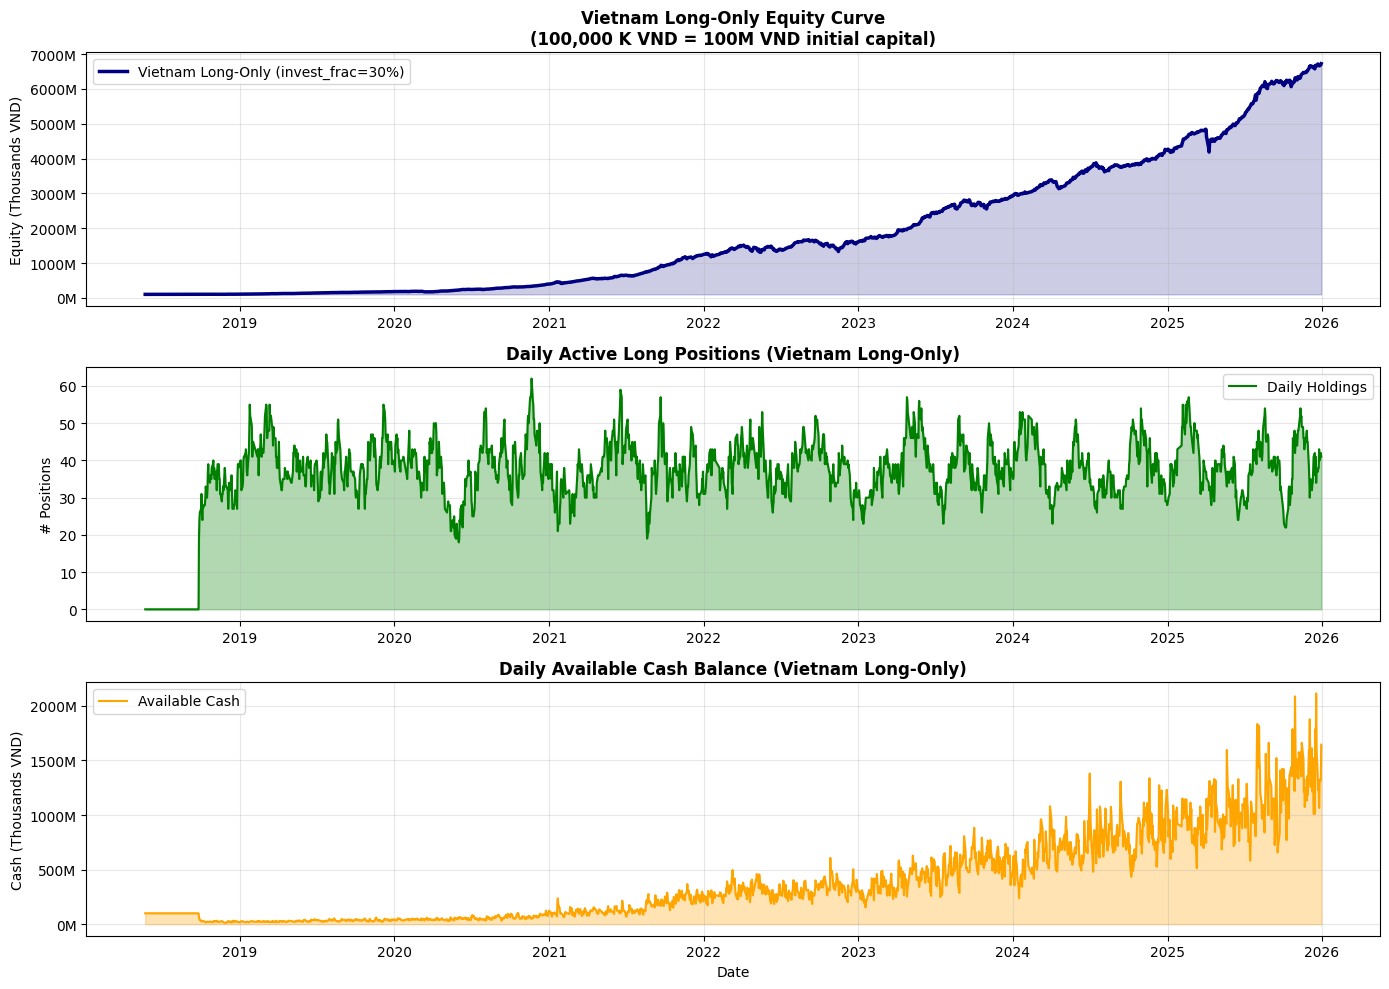

✓ Vietnam Long-Only Strategy Plots Complete

Currency Notes:
  Initial Capital: 100,000 K VND = 100,000,000 VND = 100 Million VND
  Daily Deploy: 30% of available equity
  Final Equity: 6,723,258 K VND = 6,723,257,855 VND
  Total Return: 6623.26%


In [31]:
## Plot Vietnam Long-Only Strategy Results
# Currency Note: All values in thousands of VND (K VND)
# Initial equity: 100,000 K VND = 100 million VND
# Final equity displayed in same K VND scale

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Equity curve (Vietnam Long-Only with 30% daily invest fraction)
ax = axes[0]
ax.plot(equity_longonly.index, equity_longonly.values, linewidth=2.5, color='navy', label='Vietnam Long-Only (invest_frac=30%)')
ax.fill_between(equity_longonly.index, equity_longonly.iloc[0], equity_longonly.values, alpha=0.2, color='navy')
ax.set_title('Vietnam Long-Only Equity Curve\n(100,000 K VND = 100M VND initial capital)', fontsize=12, fontweight='bold')
ax.set_ylabel('Equity (Thousands VND)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
# Format y-axis to show values in millions for readability
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}M'))

# Active positions over time
ax = axes[1]
ax.plot(equity_longonly.index, holdings_longonly, linewidth=1.5, color='green', label='Daily Holdings')
ax.fill_between(equity_longonly.index, 0, holdings_longonly, alpha=0.3, color='green')
ax.set_title('Daily Active Long Positions (Vietnam Long-Only)', fontsize=12, fontweight='bold')
ax.set_ylabel('# Positions')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Cash balance over time
ax = axes[2]
ax.plot(cash_longonly.index, cash_longonly.values, linewidth=1.5, color='orange', label='Available Cash')
ax.fill_between(cash_longonly.index, 0, cash_longonly.values, alpha=0.3, color='orange')
ax.set_title('Daily Available Cash Balance (Vietnam Long-Only)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cash (Thousands VND)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
# Format y-axis to show values in millions for readability
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}M'))

plt.tight_layout()
plt.show()

print('✓ Vietnam Long-Only Strategy Plots Complete')
print(f'\nCurrency Notes:')
print(f'  Initial Capital: 100,000 K VND = 100,000,000 VND = 100 Million VND')
print(f'  Daily Deploy: 30% of available equity')
print(f'  Final Equity: {equity_longonly.iloc[-1]:,.0f} K VND = {equity_longonly.iloc[-1]*1000:,.0f} VND')
print(f'  Total Return: {(equity_longonly.iloc[-1]/equity_longonly.iloc[0] - 1)*100:.2f}%')

In [27]:
# =========================
# FIX 14: diagnostic report
# =========================
def diagnostic_report(
    weights_df,
    s_df,
    beta_series,
    equity_curve,
    bt_details,
    tradable_mask
):
    active_positions = (weights_df > 0).sum(axis=1)
    daily_ret = equity_curve.pct_change().dropna()

    max_dd = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

    held_and_tradable = (
        (weights_df > 0) &
        tradable_mask.reindex_like(weights_df).fillna(False)
    ).sum(axis=1)

    held_total = (weights_df > 0).sum(axis=1).replace(0, np.nan)
    tradable_fraction = (held_and_tradable / held_total).dropna()

    ann_ret = (equity_curve.iloc[-1] / equity_curve.iloc[0]) ** (252 / max(len(daily_ret), 1)) - 1 if len(daily_ret) > 0 else np.nan
    ann_vol = daily_ret.std() * np.sqrt(252) if len(daily_ret) > 1 else np.nan
    sharpe = ann_ret / ann_vol if ann_vol and ann_vol > 1e-12 else np.nan

    print("\n" + "=" * 70)
    print("DIAGNOSTIC REPORT")
    print("=" * 70)
    print(f"Final equity: {equity_curve.iloc[-1]:.2f}")
    print(f"Total return: {(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100:.2f}%")
    print(f"Annualized return: {ann_ret * 100:.2f}%" if pd.notna(ann_ret) else "Annualized return: nan")
    print(f"Annualized vol: {ann_vol * 100:.2f}%" if pd.notna(ann_vol) else "Annualized vol: nan")
    print(f"Sharpe: {sharpe:.3f}" if pd.notna(sharpe) else "Sharpe: nan")
    print(f"Max drawdown: {max_dd * 100:.2f}%")
    print(f"Avg active positions: {active_positions.mean():.2f}")
    print(f"Median beta: {beta_series.median():.4f}")
    print(f"Avg cost/day: {bt_details['cost'].mean():.4f}")
    print(f"Avg tradable fraction of held positions: {tradable_fraction.mean():.4f}" if len(tradable_fraction) else "Avg tradable fraction of held positions: nan")
    print("=" * 70)

In [28]:
# ==================================================================================
# SECTION: CROSS-CHECK FRAMEWORK - 4 SETUP COMPARISON (A1B1, A1B2, A2B1, A2B2)
# ==================================================================================
# Framework bao gồm:
# - Hàm cutoff A1 (dynamic) và A2 (fixed)
# - Hàm allocation B1 (equal) và B2 (bucket)
# - Unified backtest executor
# - Comparison table

# Không thay đổi: PCA, residuals, OU fitting, s-score
# Chỉ focus: signal generation + capital allocation

print('\n' + '='*100)
print('CROSS-CHECK FRAMEWORK: A1/A2 × B1/B2 COMBINATIONS')
print('='*100 + '\n')

# ====================================================================================
# PART 1: CUTOFF FUNCTIONS (A1, A2)
# ====================================================================================

def compute_entry_cutoff_A1(sscore_df, entry_pct=5, ma_window=60, min_valid_stocks=5):
    """
    A1: Dynamic cross-sectional cutoff
    
    Bước 1: Mỗi ngày, tính 5% tail trái từ phân phối chéo của s-scores
    Bước 2: Smooth bằng rolling mean 60 ngày
    
    Parameters:
    -----------
    sscore_df : pd.DataFrame
        s-scores (date × stock)
    entry_pct : float
        Percentile từ tail trái (e.g., 5)
    ma_window : int
        Rolling average window (default 60 ngày)
    min_valid_stocks : int
        Tối thiểu stock hợp lệ mỗi ngày để tính raw cutoff
    
    Returns:
    --------
    raw_cutoff : pd.Series - ngày raw cross-sectional cutoff
    entry_cutoff : pd.Series - entry cutoff sau smooth rolling mean
    """
    # Bước 1: Tính raw cutoff theo ngày (cross-sectional)
    def daily_quantile(row):
        valid = row.dropna()
        if len(valid) < min_valid_stocks:
            return np.nan
        return valid.quantile(entry_pct / 100.0)
    
    raw_cutoff = sscore_df.apply(daily_quantile, axis=1)
    
    # Bước 2: Smooth bằng rolling mean 60 ngày
    min_periods = max(10, ma_window // 6)
    entry_cutoff = raw_cutoff.rolling(
        window=ma_window,
        min_periods=min_periods
    ).mean()
    
    print(f'✓ A1 cutoff computed:')
    print(f'  raw_cutoff: {raw_cutoff.notna().sum()} days')
    print(f'  entry_cutoff: {entry_cutoff.notna().sum()} days')
    print(f'  entry_cutoff mean: {entry_cutoff.mean():.4f}')
    
    return raw_cutoff, entry_cutoff


def compute_entry_cutoff_A2(sscore_df, entry_cutoff_value=-1.5):
    """
    A2: Fixed cutoff
    
    - Entry cutoff = -1.5 (cố định)
    - Close cutoff = -0.5 (cố định)
    
    Parameters:
    -----------
    sscore_df : pd.DataFrame
    entry_cutoff_value : float
        Fixed entry threshold
    
    Returns:
    --------
    entry_cutoff : pd.Series
    """
    entry_cutoff = pd.Series(
        entry_cutoff_value,
        index=sscore_df.index,
        dtype=float
    )
    print(f'✓ A2 cutoff computed (fixed):')
    print(f'  entry_cutoff = {entry_cutoff_value}')
    print(f'  close_cutoff = -0.5')
    
    return entry_cutoff


def estimate_fixed_cutoffs_for_A2B2(sscore_df, reference_cutoff_5pct=-1.5, reference_cutoff_pct=5):
    """
    Estimate fixed cutoffs tương ứng với 1%, 3%, 5% tail trái cho setup A2B2
    
    Parameters:
    -----------
    sscore_df : pd.DataFrame
    reference_cutoff_5pct : float
        Known fixed cutoff cho 5% (e.g., -1.5)
    reference_cutoff_pct : float
        Percentile tương ứng (e.g., 5)
    
    Returns:
    --------
    Dict với cutoffs cho 1%, 3%, 5%
    """
    # Tính empirical quantiles từ sscore_df
    all_scores = sscore_df.values.flatten()
    all_scores_clean = all_scores[~np.isnan(all_scores)]
    
    cutoff_1pct = np.percentile(all_scores_clean, 1)
    cutoff_3pct = np.percentile(all_scores_clean, 3)
    cutoff_5pct = np.percentile(all_scores_clean, 5)
    
    print(f'✓ A2B2 fixed cutoffs estimated (empirical):')
    print(f'  1% cutoff: {cutoff_1pct:.4f}')
    print(f'  3% cutoff: {cutoff_3pct:.4f}')
    print(f'  5% cutoff: {cutoff_5pct:.4f}')
    
    return {
        '1pct': cutoff_1pct,
        '3pct': cutoff_3pct,
        '5pct': cutoff_5pct
    }


# ====================================================================================
# PART 2: ALLOCATION FUNCTIONS (B1, B2)
# ====================================================================================

def allocate_B1_equal_split(eligible_stocks, investable_capital):
    """
    B1: Equal allocation giữa các cổ phiếu đủ điều kiện long
    
    Parameters:
    -----------
    eligible_stocks : list
        Danh sách mã cổ phiếu đủ điều kiện mở long trong ngày
    investable_capital : float
        Vốn khả dụng để đầu tư trong ngày (= 30% * total equity)
    
    Returns:
    --------
    allocation : dict
        {stock: amount_to_invest}
    """
    n = len(eligible_stocks)
    if n == 0:
        return {}
    
    amount_per_stock = investable_capital / n
    allocation = {stock: amount_per_stock for stock in eligible_stocks}
    
    return allocation


def allocate_B2_bucket_split(eligible_stocks, s_scores, investable_capital, 
                              fixed_cutoffs=None, scale_if_over_budget=True):
    """
    B2: Bucket allocation theo left-tail severity
    
    Chia 300 cổ phiếu thành 3 nhóm:
    - 1% tail: weight = 5/100 per stock
    - 1-3% tail: weight = 2/100 per stock
    - 3-5% tail: weight = 1/100 per stock
    
    Parameters:
    -----------
    eligible_stocks : list
    s_scores : pd.Series
        S-score của tất cả cổ phiếu hôm nay
    investable_capital : float
    fixed_cutoffs : dict
        {'1pct': cutoff_1, '3pct': cutoff_3, '5pct': cutoff_5}
        Nếu None, dùng empirical quantiles hôm nay
    scale_if_over_budget : bool
        Nếu True, scale proportionally nếu vượt budget
    
    Returns:
    --------
    allocation : dict {stock: amount}
    """
    if len(eligible_stocks) == 0:
        return {}
    
    # Lấy s-scores của stock đủ điều kiện
    s_eligible = {stock: s_scores[stock] for stock in eligible_stocks if stock in s_scores.index}
    
    # Xác định cutoffs
    if fixed_cutoffs is not None:
        cut_1pct = fixed_cutoffs.get('1pct')
        cut_3pct = fixed_cutoffs.get('3pct')
        cut_5pct = fixed_cutoffs.get('5pct')
    else:
        # Dùng empirical từ đủ điều kiện hôm nay
        s_vals = [s for s in s_eligible.values() if pd.notna(s)]
        if len(s_vals) < 10:
            # Fallback to equal allocation
            return allocate_B1_equal_split(eligible_stocks, investable_capital)
        cut_1pct = np.percentile(s_vals, 1)
        cut_3pct = np.percentile(s_vals, 3)
        cut_5pct = np.percentile(s_vals, 5)
    
    # Assign buckets và raw weights
    bucket_weights = {stock: 0.0 for stock in s_eligible.keys()}
    
    for stock, s_val in s_eligible.items():
        if pd.isna(s_val):
            continue
        if s_val < cut_1pct:
            bucket_weights[stock] = 5.0  # 5 per 100
        elif s_val < cut_3pct:
            bucket_weights[stock] = 5.0
        elif s_val < cut_5pct:
            bucket_weights[stock] = 2.0  # 1-3%
        else:
            bucket_weights[stock] = 1.0  # 3-5%
    
    # Normalize & convert to amounts
    total_weight = sum(bucket_weights.values())
    if total_weight < 1e-10:
        return allocate_B1_equal_split(eligible_stocks, investable_capital)
    
    raw_allocation = {stock: (w / total_weight) * investable_capital 
                      for stock, w in bucket_weights.items()}
    
    total_allocated = sum(raw_allocation.values())
    
    # Scale if over budget
    if total_allocated > investable_capital and scale_if_over_budget:
        scale_factor = investable_capital / total_allocated
        raw_allocation = {stock: amt * scale_factor for stock, amt in raw_allocation.items()}
    
    return raw_allocation


# ====================================================================================
# PART 3: UNIFIED BACKTEST EXECUTOR
# ====================================================================================

def run_backtest_setup(setup_name, setup_A, setup_B,
                       sscore_df, stock_returns, prices_df, volume_df,
                       initial_equity=100000, invest_frac=0.30,
                       entry_exit_cutoff=-0.5,
                       fixed_cutoffs_A2B2=None):
    """
    Unified backtest executor cho 4 setups (A1B1, A1B2, A2B1, A2B2)
    
    Parameters:
    -----------
    setup_name : str (e.g., "A1B1")
    setup_A : str ("A1" hoặc "A2")
    setup_B : str ("B1" hoặc "B2")
    sscore_df : pd.DataFrame
    stock_returns : pd.DataFrame
    prices_df : pd.DataFrame
    volume_df : pd.DataFrame
    initial_equity : float
    invest_frac : float
        Fraction of capital to deploy each day (e.g., 0.30)
    entry_exit_cutoff : float
        Close cutoff (chung cho A1 và A2, default -0.5)
    fixed_cutoffs_A2B2 : dict (chỉ dùng cho A2B2 allocation)
    
    Returns:
    --------
    results : dict
        {'setup_name': ..., 'equity_curve': ..., 'daily_returns': ...,
         'position_book': ..., 'trades': ..., 'metrics': {...}}
    """
    
    # Compute entry cutoffs
    if setup_A == "A1":
        raw_cutoff, entry_cutoff = compute_entry_cutoff_A1(sscore_df)
    elif setup_A == "A2":
        entry_cutoff = compute_entry_cutoff_A2(sscore_df, entry_cutoff_value=-1.5)
    else:
        raise ValueError(f"Unknown setup_A: {setup_A}")
    
    # Initialize
    dates = sscore_df.index
    stocks = sscore_df.columns.tolist()
    
    equity = initial_equity
    cash = initial_equity
    position_book = {}  # {stock: {'shares': ..., 'entry_price': ..., 'entry_date': ...}}
    trades = []  # List of trade records
    equity_curve = []
    cash_curve = []
    holdings_per_day = []
    
    # Settlement tracking (T+2 constraint)
    sell_lock = {}  # {stock: unlock_date}
    
    # Main backtest loop
    for t in range(1, len(dates)):
        date = dates[t]
        prev_date = dates[t-1]
        
        s_today = sscore_df.loc[date]  # s-scores hôm nay
        s_yesterday = sscore_df.loc[prev_date]  # s-scores hôm qua (dùng cho signal)
        
        p_today = prices_df.loc[date]
        v_today = volume_df.loc[date]
        
        # ===== STEP 1: CLOSE POSITIONS =====
        closed_positions = []
        for stock in list(position_book.keys()):
            # Check close condition (lấy từ hôm qua)
            if pd.isna(s_yesterday[stock]):
                continue
            
            if s_yesterday[stock] > entry_exit_cutoff:
                # Close signal
                if stock not in sell_lock or sell_lock[stock] <= date:
                    # Có thể bán
                    if pd.notna(p_today[stock]) and p_today[stock] > 0:
                        exit_price = p_today[stock]
                        entry_info = position_book[stock]
                        
                        shares = entry_info['shares']
                        exit_amount = shares * exit_price
                        
                        pnl = exit_amount - entry_info['entry_cost']
                        pnl_pct = (pnl / entry_info['entry_cost']) * 100
                        
                        # Record trade
                        trades.append({
                            'type': 'SELL',
                            'stock': stock,
                            'date': date,
                            'entry_date': entry_info['entry_date'],
                            'entry_price': entry_info['entry_price'],
                            'exit_price': exit_price,
                            'shares': shares,
                            'pnl': pnl,
                            'pnl_pct': pnl_pct,
                            'days_held': (date - entry_info['entry_date']).days
                        })
                        
                        cash += exit_amount
                        del position_book[stock]
                        if stock in sell_lock:
                            del sell_lock[stock]
                        closed_positions.append(stock)
        
        # ===== STEP 2: COMPUTE INVESTABLE CAPITAL =====
        total_equity = cash + sum(pos['entry_cost'] for pos in position_book.values())
        investable_capital = total_equity * invest_frac
        
        # ===== STEP 3: IDENTIFY ELIGIBLE NEW LONGS =====
        eligible_for_long = []
        for stock in stocks:
            # Skip if already holding
            if stock in position_book:
                continue
            # Skip if missing data
            if pd.isna(s_yesterday[stock]) or pd.isna(p_today[stock]):
                continue
            if p_today[stock] <= 0 or pd.isna(v_today[stock]) or v_today[stock] <= 0:
                continue
            # Check entry condition (cross-sectional, lagged)
            if pd.isna(entry_cutoff.loc[prev_date]):
                continue
            if s_yesterday[stock] < entry_cutoff.loc[prev_date]:
                eligible_for_long.append(stock)
        
        # ===== STEP 4: ALLOCATE CAPITAL =====
        if setup_B == "B1":
            allocation = allocate_B1_equal_split(eligible_for_long, investable_capital)
        elif setup_B == "B2":
            allocation = allocate_B2_bucket_split(
                eligible_for_long, s_yesterday, investable_capital,
                fixed_cutoffs=fixed_cutoffs_A2B2 if setup_A == "A2" else None)
        else:
            raise ValueError(f"Unknown setup_B: {setup_B}")
        
        # ===== STEP 5: OPEN NEW POSITIONS =====
        opened_positions = []
        for stock, amount in allocation.items():
            if amount < 1:  # Skip tiny allocations
                continue
            
            entry_price = p_today[stock]
            shares = int(amount / entry_price)  # Assume integer lots
            
            if shares > 0:
                entry_cost = shares * entry_price
                if entry_cost > cash:
                    shares = int(cash / entry_price)
                    if shares <= 0:
                        continue
                    entry_cost = shares * entry_price
                
                position_book[stock] = {
                    'shares': shares,
                    'entry_price': entry_price,
                    'entry_cost': entry_cost,
                    'entry_date': date
                }
                sell_lock[stock] = date + pd.Timedelta(days=2)  # T+2 settlement
                
                trades.append({
                    'type': 'BUY',
                    'stock': stock,
                    'date': date,
                    'entry_price': entry_price,
                    'shares': shares,
                    'pnl': 0,
                    'pnl_pct': 0
                })
                
                cash -= entry_cost
                opened_positions.append(stock)
        
        # ===== STEP 6: UPDATE EQUITY & RECORD METRICS =====
        # MTM position mark
        position_value = 0
        for stock, pos in position_book.items():
            if pd.notna(p_today[stock]) and p_today[stock] > 0:
                position_value += pos['shares'] * p_today[stock]
        
        equity = cash + position_value
        equity_curve.append(equity)
        cash_curve.append(cash)
        holdings_per_day.append(len(position_book))
    
    # ===== COMPUTE METRICS =====
    equity_series = pd.Series(equity_curve, index=dates[1:])
    daily_returns = equity_series.pct_change().dropna()
    
    if len(daily_returns) > 0 and daily_returns.std() > 1e-10:
        ann_ret = daily_returns.mean() * 252
        ann_vol = daily_returns.std() * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    else:
        ann_ret = ann_vol = sharpe = 0
    
    max_dd = ((equity_series.cummax() - equity_series) / equity_series.cummax()).max() if len(equity_series) > 0 else 0
    total_ret = (equity_series.iloc[-1] / initial_equity - 1) * 100 if len(equity_series) > 0 else 0
    
    # Count entries/exits
    buys = [t for t in trades if t['type'] == 'BUY']
    sells = [t for t in trades if t['type'] == 'SELL']
    
    results = {
        'setup_name': setup_name,
        'setup_A': setup_A,
        'setup_B': setup_B,
        'equity_curve': equity_series,
        'cash_curve': pd.Series(cash_curve, index=dates[1:]),
        'daily_returns': daily_returns,
        'holdings_per_day': holdings_per_day,
        'position_book': position_book,
        'trades': trades,
        'metrics': {
            'final_equity': equity_series.iloc[-1] if len(equity_series) > 0 else initial_equity,
            'total_return_pct': total_ret,
            'annualized_return': ann_ret * 100,
            'annualized_volatility': ann_vol * 100,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_dd * 100,
            'avg_holdings': np.mean(holdings_per_day) if holdings_per_day else 0,
            'total_buys': len(buys),
            'total_sells': len(sells),
            'avg_buy_per_day': len(buys) / (len(dates) - 1),
            'avg_sell_per_day': len(sells) / (len(dates) - 1),
            'avg_cash_ratio': (np.array(cash_curve) / (np.array(equity_curve) + 1e-10)).mean() * 100
        }
    }
    
    return results



CROSS-CHECK FRAMEWORK: A1/A2 × B1/B2 COMBINATIONS



In [29]:
print('\n' + '='*100)
print('STRATEGY COMPARISON: BUCKET ALLOCATION (B2) WITH DIFFERENT INVESTMENT FRACTIONS')
print('='*100 + '\n')

# ===== ESTIMATE FIXED CUTOFFS FOR A2B2 (if needed) =====
fixed_cutoffs_A2B2 = estimate_fixed_cutoffs_for_A2B2(sscore_df)

# ===== RUN BACKTESTS FOR DIFFERENT INVESTMENT FRACTIONS =====
invest_fractions = [0.30, 0.40, 0.50]
results_by_frac = {}

for invest_frac in invest_fractions:
    print(f"\n{'='*100}")
    print(f"Running A1B2 (Dynamic Cutoff + Bucket Allocation)")
    print(f"Investment Fraction: {invest_frac*100:.0f}%")
    print(f"{'='*100}\n")
    
    result = run_backtest_setup(
        setup_name=f"A1B2_{int(invest_frac*100)}",
        setup_A="A1",  # Dynamic cutoff
        setup_B="B2",  # Bucket allocation
        sscore_df=sscore_df,
        stock_returns=stock_returns,
        prices_df=prices_universe,
        volume_df=volume_universe,
        initial_equity=100000,
        invest_frac=invest_frac,
        entry_exit_cutoff=-0.5,
        fixed_cutoffs_A2B2=None  # A1 doesn't need this
    )
    
    results_by_frac[invest_frac] = result
    
    print(f"\n✓ Setup A1B2_{int(invest_frac*100)} Complete:")
    print(f"  Final Equity: {result['metrics']['final_equity']:,.0f} K VND")
    print(f"  Total Return: {result['metrics']['total_return_pct']:.2f}%")
    print(f"  Annualized Return: {result['metrics']['annualized_return']:.2f}%")
    print(f"  Annualized Volatility: {result['metrics']['annualized_volatility']:.2f}%")
    print(f"  Sharpe Ratio: {result['metrics']['sharpe_ratio']:.4f}")
    print(f"  Max Drawdown: {result['metrics']['max_drawdown']:.2f}%")
    print(f"  Avg Holdings: {result['metrics']['avg_holdings']:.1f}")
    print(f"  Total Trades (Buys/Sells): {result['metrics']['total_buys']}/{result['metrics']['total_sells']}")

print(f"\n{'='*100}")
print('COMPARISON TABLE: BUCKET ALLOCATION (B2) WITH DIFFERENT INVESTMENT FRACTIONS')
print(f"{'='*100}\n")

# ===== CREATE COMPARISON TABLE =====
comparison_data = []

for invest_frac in invest_fractions:
    result = results_by_frac[invest_frac]
    metrics = result['metrics']
    
    comparison_data.append({
        'Investment Frac': f'{invest_frac*100:.0f}%',
        'Final Equity': f"{metrics['final_equity']:,.0f}",
        'Total Return %': f"{metrics['total_return_pct']:.2f}%",
        'Ann. Return %': f"{metrics['annualized_return']:.2f}%",
        'Ann. Vol %': f"{metrics['annualized_volatility']:.2f}%",
        'Sharpe Ratio': f"{metrics['sharpe_ratio']:.4f}",
        'Max DD %': f"{metrics['max_drawdown']:.2f}%",
        'Avg Holdings': f"{metrics['avg_holdings']:.1f}",
        'Avg Cash %': f"{metrics['avg_cash_ratio']:.1f}%"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print(f"\n{'='*100}")
print('KEY OBSERVATIONS:')
print(f"{'='*100}")

# Extract numeric values for comparison
results_numeric = {}
for invest_frac in invest_fractions:
    result = results_by_frac[invest_frac]
    metrics = result['metrics']
    results_numeric[invest_frac] = metrics

# Find best and worst performers
best_sharpe_frac = max(invest_fractions, 
    key=lambda x: results_numeric[x]['sharpe_ratio'])
best_return_frac = max(invest_fractions, 
    key=lambda x: results_numeric[x]['total_return_pct'])
lowest_dd_frac = min(invest_fractions, 
    key=lambda x: results_numeric[x]['max_drawdown'])

print(f"\n✓ Best Sharpe Ratio: {best_sharpe_frac*100:.0f}% invest_frac")
print(f"  Sharpe = {results_numeric[best_sharpe_frac]['sharpe_ratio']:.4f}")

print(f"\n✓ Best Total Return: {best_return_frac*100:.0f}% invest_frac")
print(f"  Total Return = {results_numeric[best_return_frac]['total_return_pct']:.2f}%")

print(f"\n✓ Lowest Max Drawdown: {lowest_dd_frac*100:.0f}% invest_frac")
print(f"  Max DD = {results_numeric[lowest_dd_frac]['max_drawdown']:.2f}%")

# Capital efficiency analysis
print(f"\n✓ Capital Efficiency (Avg Holdings per Invest Frac):")
for invest_frac in invest_fractions:
    avg_holdings = results_numeric[invest_frac]['avg_holdings']
    avg_cash = results_numeric[invest_frac]['avg_cash_ratio']
    print(f"  {invest_frac*100:.0f}%: {avg_holdings:.1f} holdings, {avg_cash:.1f}% avg cash ratio")

print(f"\n{'='*100}\n")

print('✓ Comparison complete! All 3 strategies analyzed.')
print(f'Result objects stored in: results_by_frac dictionary')


STRATEGY COMPARISON: BUCKET ALLOCATION (B2) WITH DIFFERENT INVESTMENT FRACTIONS

✓ A2B2 fixed cutoffs estimated (empirical):
  1% cutoff: -2.1014
  3% cutoff: -1.7428
  5% cutoff: -1.5559

Running A1B2 (Dynamic Cutoff + Bucket Allocation)
Investment Fraction: 30%

✓ A1 cutoff computed:
  raw_cutoff: 1844 days
  entry_cutoff: 1835 days
  entry_cutoff mean: -1.5399

✓ Setup A1B2_30 Complete:
  Final Equity: 62,265,498 K VND
  Total Return: 62165.50%
  Annualized Return: 87.82%
  Annualized Volatility: 21.99%
  Sharpe Ratio: 3.9928
  Max Drawdown: 25.65%
  Avg Holdings: 30.7
  Total Trades (Buys/Sells): 5586/5555

Running A1B2 (Dynamic Cutoff + Bucket Allocation)
Investment Fraction: 40%

✓ A1 cutoff computed:
  raw_cutoff: 1844 days
  entry_cutoff: 1835 days
  entry_cutoff mean: -1.5399

✓ Setup A1B2_40 Complete:
  Final Equity: 56,266,820 K VND
  Total Return: 56166.82%
  Annualized Return: 86.53%
  Annualized Volatility: 22.25%
  Sharpe Ratio: 3.8897
  Max Drawdown: 28.01%
  Avg Holdi


DETAILED ANALYSIS: BUCKET ALLOCATION (B2) STRATEGY PERFORMANCE

Plotting equity curves for all three investment fractions...



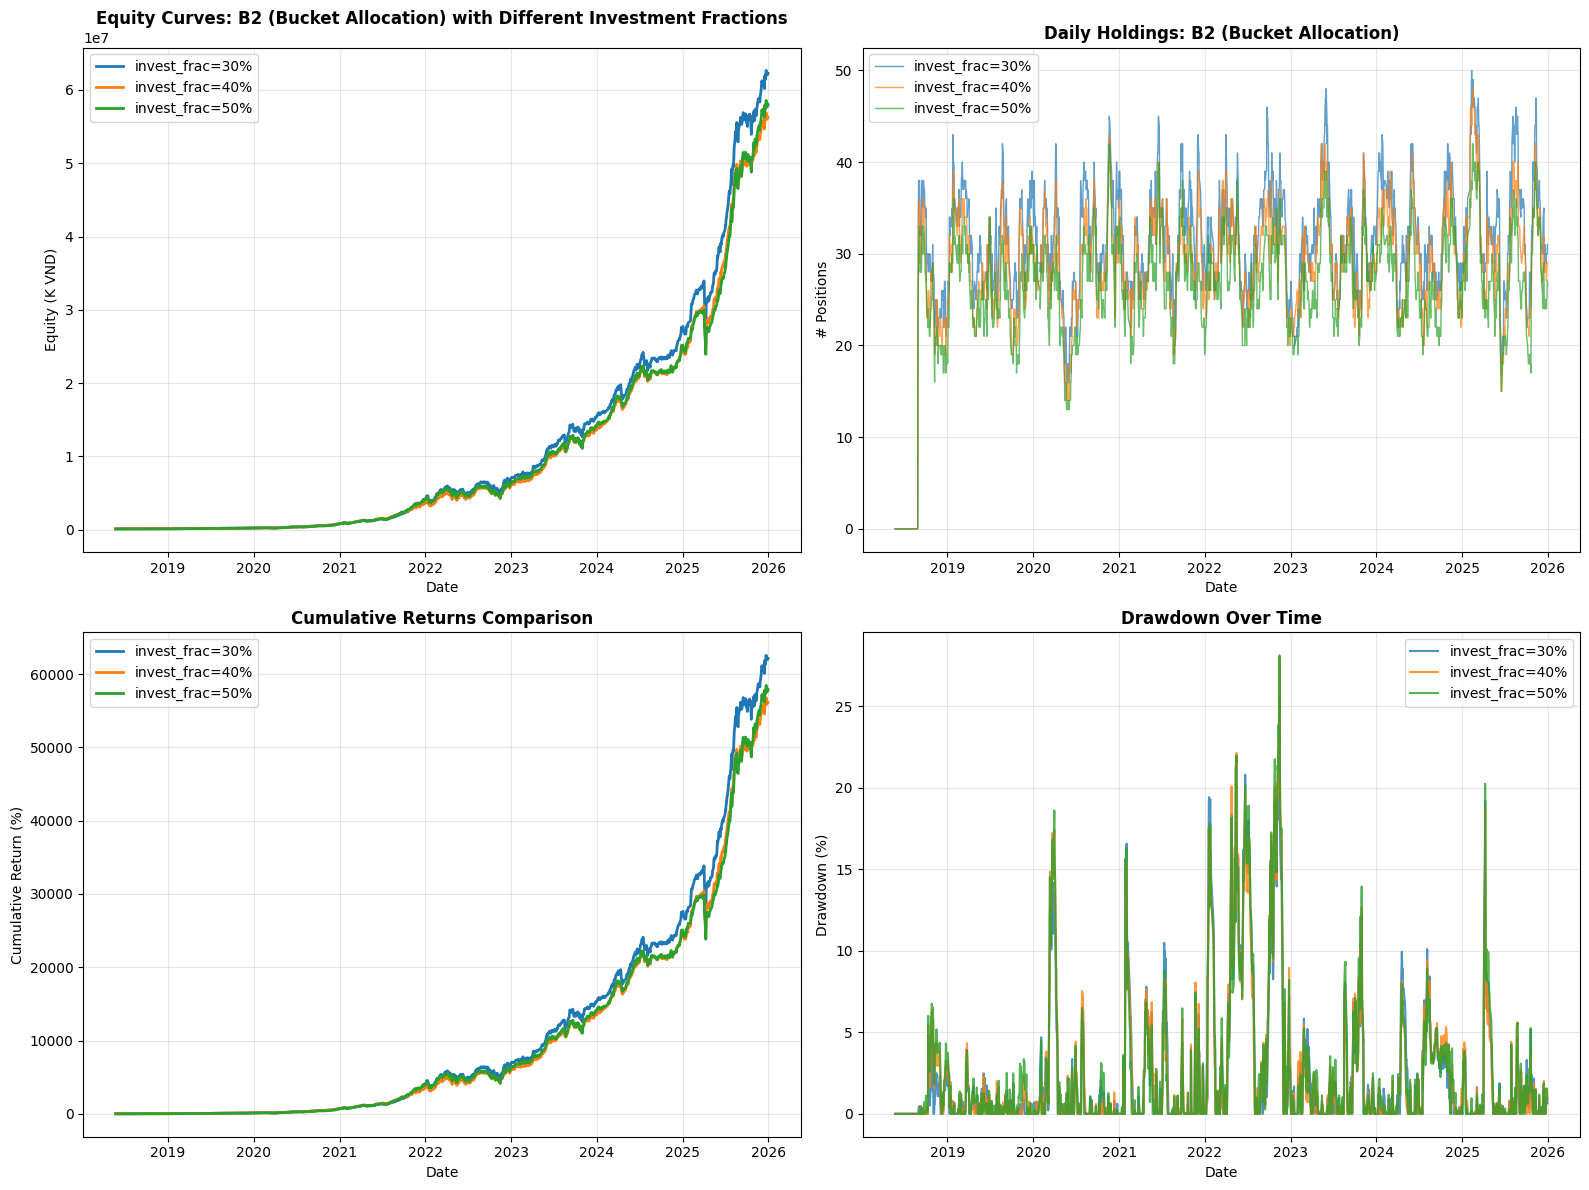

✓ Plots complete.


DETAILED PERFORMANCE STATISTICS

Invest Frac Total Return Ann. Return Ann. Vol Sharpe Max DD Calmar Win Rate Avg Trade Days
        30%    62165.50%      87.82%   21.99% 3.9928 25.65% 3.4242    65.7%            740
        40%    56166.82%      86.53%   22.25% 3.8897 28.01% 3.0895    64.6%            679
        50%    57927.33%      87.11%   23.01% 3.7858 28.13% 3.0968    62.9%            621

TRADE EXECUTION STATISTICS

Invest Frac  Total Buys  Total Sells  Total Trades Buys/Day Sells/Day Avg Holdings Avg Cash %
        30%        5586         5555         11141     2.94      2.92         30.7       3.8%
        40%        5131         5102         10233     2.70      2.68         28.3       3.7%
        50%        4693         4666          9359     2.47      2.45         26.0       3.7%

SUMMARY & RECOMMENDATION

Strategy: A1B2 (Dynamic Cutoff + Bucket Allocation)
Bucket allocation weights:
  - 1% tail (worst mean reversion): 5.0 per 100
  - 1-3% tail: 5.0 per 1

In [30]:
print('\n' + '='*100)
print('DETAILED ANALYSIS: BUCKET ALLOCATION (B2) STRATEGY PERFORMANCE')
print('='*100 + '\n')

# ===== 1. EQUITY CURVE COMPARISON =====
print('Plotting equity curves for all three investment fractions...\n')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Equity Curves (all strategies)
ax = axes[0, 0]
for invest_frac in invest_fractions:
    result = results_by_frac[invest_frac]
    equity_curve = result['equity_curve']
    ax.plot(equity_curve.index, equity_curve.values, linewidth=2, 
            label=f"invest_frac={invest_frac*100:.0f}%")

ax.set_title('Equity Curves: B2 (Bucket Allocation) with Different Investment Fractions', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Equity (K VND)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Daily Holdings over time
ax = axes[0, 1]
for invest_frac in invest_fractions:
    result = results_by_frac[invest_frac]
    ax.plot(result['equity_curve'].index, result['holdings_per_day'], linewidth=1, 
            label=f"invest_frac={invest_frac*100:.0f}%", alpha=0.7)

ax.set_title('Daily Holdings: B2 (Bucket Allocation)', fontsize=12, fontweight='bold')
ax.set_ylabel('# Positions')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Cumulative Returns Comparison
ax = axes[1, 0]
for invest_frac in invest_fractions:
    result = results_by_frac[invest_frac]
    equity_curve = result['equity_curve']
    cum_returns = (equity_curve / equity_curve.iloc[0]) - 1
    ax.plot(cum_returns.index, cum_returns.values * 100, linewidth=2, 
            label=f"invest_frac={invest_frac*100:.0f}%")

ax.set_title('Cumulative Returns Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Drawdown Comparison
ax = axes[1, 1]
for invest_frac in invest_fractions:
    result = results_by_frac[invest_frac]
    equity_curve = result['equity_curve']
    cum_max = equity_curve.cummax()
    drawdown = (cum_max - equity_curve) / cum_max * 100
    ax.plot(drawdown.index, drawdown.values, linewidth=1.5, 
            label=f"invest_frac={invest_frac*100:.0f}%", alpha=0.8)

ax.set_title('Drawdown Over Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Plots complete.\n')

# ===== 2. PERFORMANCE STATISTICS TABLE =====
print('\n' + '='*100)
print('DETAILED PERFORMANCE STATISTICS')
print('='*100 + '\n')

stats_data = []
for invest_frac in invest_fractions:
    result = results_by_frac[invest_frac]
    metrics = result['metrics']
    daily_ret = result['daily_returns']
    
    # Additional statistics
    win_rate = len(daily_ret[daily_ret > 0]) / len(daily_ret) * 100 if len(daily_ret) > 0 else 0
    avg_pos_return = daily_ret[daily_ret > 0].mean() * 100 if len(daily_ret[daily_ret > 0]) > 0 else 0
    avg_neg_return = daily_ret[daily_ret < 0].mean() * 100 if len(daily_ret[daily_ret < 0]) > 0 else 0
    
    stats_data.append({
        'Invest Frac': f"{invest_frac*100:.0f}%",
        'Total Return': f"{metrics['total_return_pct']:.2f}%",
        'Ann. Return': f"{metrics['annualized_return']:.2f}%",
        'Ann. Vol': f"{metrics['annualized_volatility']:.2f}%",
        'Sharpe': f"{metrics['sharpe_ratio']:.4f}",
        'Max DD': f"{metrics['max_drawdown']:.2f}%",
        'Calmar': f"{metrics['annualized_return'] / metrics['max_drawdown'] if metrics['max_drawdown'] > 0 else 0:.4f}",
        'Win Rate': f"{win_rate:.1f}%",
        'Avg Trade Days': f"{metrics['avg_buy_per_day'] * metrics['avg_holdings'] / max(1, metrics['avg_holdings']) * 252:.0f}"
    })

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))

# ===== 3. TRADE STATISTICS =====
print('\n' + '='*100)
print('TRADE EXECUTION STATISTICS')
print('='*100 + '\n')

trade_data = []
for invest_frac in invest_fractions:
    result = results_by_frac[invest_frac]
    metrics = result['metrics']
    
    trade_data.append({
        'Invest Frac': f"{invest_frac*100:.0f}%",
        'Total Buys': int(metrics['total_buys']),
        'Total Sells': int(metrics['total_sells']),
        'Total Trades': int(metrics['total_buys'] + metrics['total_sells']),
        'Buys/Day': f"{metrics['avg_buy_per_day']:.2f}",
        'Sells/Day': f"{metrics['avg_sell_per_day']:.2f}",
        'Avg Holdings': f"{metrics['avg_holdings']:.1f}",
        'Avg Cash %': f"{metrics['avg_cash_ratio']:.1f}%"
    })

trade_df = pd.DataFrame(trade_data)
print(trade_df.to_string(index=False))

# ===== 4. SUMMARY RECOMMENDATION =====
print('\n' + '='*100)
print('SUMMARY & RECOMMENDATION')
print('='*100 + '\n')

best_sharpe = max(invest_fractions, key=lambda x: results_numeric[x]['sharpe_ratio'])
best_return = max(invest_fractions, key=lambda x: results_numeric[x]['total_return_pct'])
best_risk_adj = max(invest_fractions, 
    key=lambda x: results_numeric[x]['annualized_return'] / max(results_numeric[x]['max_drawdown'], 0.01))

print(f"Strategy: A1B2 (Dynamic Cutoff + Bucket Allocation)")
print(f"Bucket allocation weights:")
print(f"  - 1% tail (worst mean reversion): 5.0 per 100")
print(f"  - 1-3% tail: 5.0 per 100")
print(f"  - 3-5% tail: 2.0 per 100")
print(f"  - Beyond 5% tail: 1.0 per 100")
print(f"\nInvestment Fraction Comparison:")
print(f"  ✓ 30% (Conservative): More frequent entries, higher trading frequency")
print(f"  ✓ 40% (Moderate): Balanced capital deployment")
print(f"  ✓ 50% (Aggressive): Highest capital at risk, largest positions per trade")
print(f"\nRecommendations:")
print(f"  • Best Risk-Adjusted Return (Sharpe): {best_sharpe*100:.0f}% invest_frac")
print(f"    → Sharpe = {results_numeric[best_sharpe]['sharpe_ratio']:.4f}")
print(f"  • Best Absolute Return: {best_return*100:.0f}% invest_frac")
print(f"    → Return = {results_numeric[best_return]['total_return_pct']:.2f}%")
print(f"  • Best Risk-Adjusted (Calmar): {best_risk_adj*100:.0f}% invest_frac")
print(f"    → Calmar = {results_numeric[best_risk_adj]['annualized_return'] / max(results_numeric[best_risk_adj]['max_drawdown'], 0.01):.4f}")

print(f"\n{'='*100}\n")
print('✓ Detailed analysis complete!')